# Deep Learning — Module 2: Training & Optimization · Part 3
## Regularization — Preventing Overfitting

> Every concept in three layers: **Intuition → Math → Code**

---

## Table of Contents

| Section | Topic |
|---------|-------|
| **1** | Bias-Variance Tradeoff |
| **2** | L2 Regularization (Weight Decay) |
| **3** | L1 Regularization & Sparsity |
| **4** | Elastic Net (L1 + L2) |
| **5** | Dropout — Random Neuron Silencing |
| **6** | Inverted Dropout & Test-time Behaviour |
| **7** | Early Stopping |
| **8** | Weighted Loss (Class Imbalance) |
| **9** | PyTorch Regularization Demo |
| **10** | Master Interview Q&A Cheatsheet |


In [11]:
# ── All imports ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "axes.prop_cycle": plt.cycler(color=[
        "#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860"
    ])
})
print("Imports ready ✓")


Imports ready ✓


## 1. The Bias-Variance Tradeoff: The Core Problem of Machine Learning

At the heart of every machine learning algorithm, from a simple Linear Regression to a massive Large Language Model, lies a tug-of-war known as the **Bias-Variance Tradeoff**. Understanding this concept is the key to mastering model generalization and knowing exactly when and how to apply regularization.

When we train a model, our ultimate goal is to minimize the **Expected Test Error** (how completely wrong the model will be on data it has never seen before). 

Mathematically, this error can be decomposed into three distinct parts:
1.  **Bias (The Error from Bad Assumptions):** The difference between the average prediction of our model and the correct value. A high-bias model pays very little attention to the training data and oversimplifies the problem. *(e.g., trying to fit a perfectly straight line through curved, complex data).*
2.  **Variance (The Error from Hyper-Sensitivity):** How much the model's predictions jump around for a given data point if we train it on different datasets. A high-variance model pays extremely close attention to the noisy training data and fails to generalize. *(e.g., drawing a jagged line that perfectly touches every single outlier point).*
3.  **Irreducible Error (The Noise):** The inherent noise present in the universe. Even if you possessed a perfect model, the data itself contains random, unmeasurable variations. This error can absolutely never be removed.

---

### The Intuition: The Target Game

Imagine you are playing darts. 
*   **The Bullseye:** The True Target Function (the perfect relationship in the universe).
*   **The Darts:** The predictions made by your model when trained on slightly different variations of the training data.

| State | Visual | What Happens During Training | Result |
| :--- | :--- | :--- | :--- |
| **High Bias / Low Variance** | **Underfitting.** All darts are clustered tightly together in a neat little group, but they are all hitting the wall 3 feet to the right of the target. | The model is too rigid (e.g., a simple linear line). It completely ignores the complexities of the data. | Performs poorly on Training Data. Performs poorly on Test Data. |
| **Low Bias / High Variance** | **Overfitting.** The darts are perfectly centered around the bullseye on average, but they are scattered wildly in every direction across the entire board. | The model is too flexible (e.g., a 100-layer neural network with no regularization). It perfectly memorizes the noise of the specific training set it saw. | Performs perfectly on Training Data. Performs poorly on Test Data. |
| **Low Bias / Low Variance** | **The Ideal Scenario.** All darts are clustered tightly together dead center in the bullseye. | The model perfectly captures the true underlying pattern while completely ignoring the random background noise. | Performs well on Training Data. Performs perfectly on Test Data. |

**The Tradeoff:** As you increase the complexity of your model (add more layers, more parameters), your **Bias decreases** (you can model complex curves), but your **Variance increases** (you become highly sensitive to noise). 

---

### The Mathematical Derivation

Let's prove this mathematically. Why does the Total Expected Error always equal $Bias^2 + Variance + Noise$?

**1. The Setup:**
Assume there is a true, perfect function in the universe $f(x)$. 
However, the data we observe $y$ is imperfect. It contains random noise $\epsilon$ with a mean of $0$ and a variance of $\sigma^2$.
$$y = f(x) + \epsilon$$

We train our model to predict this target. We will call our model's prediction $\hat{f}(x)$.

**2. The Expected Squared Error:**
What happens when we calculate the expected mean squared error (MSE) of our model attempting to predict a new data point $y$?
$$E[(y - \hat{f}(x))^2]$$

**3. The Expansion:**
Let's substitute $y$ with its true definition $f(x) + \epsilon$ and aggressively expand the polynomial:
$$E[(f(x) + \epsilon - \hat{f}(x))^2]$$
$$E[((f(x) - \hat{f}(x)) + \epsilon)^2]$$
$$E[(f(x) - \hat{f}(x))^2 + 2\epsilon(f(x) - \hat{f}(x)) + \epsilon^2]$$

Because the Expectation $E[\dots]$ is a linear operator, we can distribute it across the terms:
$$E[(f(x) - \hat{f}(x))^2] + E[2\epsilon(f(x) - \hat{f}(x))] + E[\epsilon^2]$$

**4. Simplifying the Terms:**
*   **Term 3 ($E[\epsilon^2]$):** We defined the noise $\epsilon$ as having a mean of $0$ and a variance of $\sigma^2$. Therefore, $E[\epsilon^2] = \sigma^2$. This is our **Irreducible Error**.
*   **Term 2 ($E[2\epsilon(f(x) - \hat{f}(x))]$):** Because the noise $\epsilon$ is completely random and independent of our model $\hat{f}(x)$, we can pull the expectations apart: $2 \cdot E[\epsilon] \cdot E[f(x) - \hat{f}(x)]$. Since the mean of the noise $E[\epsilon] = 0$, this entire term cancels out to zero!

Therefore, we are left with:
$$E[(y - \hat{f}(x))^2] = E[(f(x) - \hat{f}(x))^2] + \sigma^2$$

**5. The Final Trick (Adding Zero):**
Now we must break down the remaining term: $E[(f(x) - \hat{f}(x))^2]$. 
This is the expected difference between the True function and our Model.
We use a classic math trick: add and subtract the Expected Value of our model $E[\hat{f}(x)]$ inside the square. (Adding and subtracting the same thing equals zero, so we aren't changing the equation).

$$E[ (f(x) - E[\hat{f}(x)] + E[\hat{f}(x)] - \hat{f}(x))^2 ]$$

Let's group the terms:
$$E[ [ (f(x) - E[\hat{f}(x)]) + (E[\hat{f}(x)] - \hat{f}(x)) ]^2 ]$$

Expand the polynomial $(A + B)^2 = A^2 + B^2 + 2AB$:
$$E[ (f(x) - E[\hat{f}(x)])^2 ] + E[ (E[\hat{f}(x)] - \hat{f}(x))^2 ] + E[ 2(f(x) - E[\hat{f}(x)])(E[\hat{f}(x)] - \hat{f}(x)) ]$$

*   **Term A ($E[ (f(x) - E[\hat{f}(x)])^2 ]$):** This is the squared difference between the True Function $f(x)$ and the *average* prediction of our model $E[\hat{f}(x)]$. By definition, this is **$Bias^2$**. Because Bias is a constant theoretical value, the $E[]$ wrapper drops away.
*   **Term B ($E[ (E[\hat{f}(x)] - \hat{f}(x))^2 ]$):** This is the expected squared difference between the *average* prediction of our model and the *actual* prediction of our model on a specific run. By definition, this is the statistical **Variance**.
*   **Term C (The Cross Term):** Just like before, because the error fluctuates around the mean, the expected value of this term cancels out to **$0$**.

**6. The Grand Finale:**
Plugging all three pieces back together, we arrive at the absolute mathematical truth of Machine Learning:

$$Error = Bias^2 + Variance + Irreducible\_Noise$$
$$Err(x) = (E[\hat{f}(x)] - f(x))^2 + E[(\hat{f}(x) - E[\hat{f}(x)])^2] + \sigma_e^2$$

---

### How Regularization Affects the Tradeoff

The entire point of Regularization (like L2 Weight Decay, Dropout, Early Stopping) is to purposefully manipulate this equation. 

A massive neural network is incredibly powerful. As $t \rightarrow \infty$, it will drive its **Bias to 0**, memorizing the training data perfectly. However, because it memorizes the noise, its **Variance spikes to infinity**. 

Regularization forcefully restricts the capacity of the model. 
*   **We purposefully inject a small amount of Bias into the model...**
*   **...in exchange for a massive reduction in Variance.**

By shifting the model slightly to the left on the tradeoff curve, the Total Error drops, and the model begins to generalize to the real world.

---

### Master Interview Q&A: Bias-Variance

> **Q: What is the mathematical definition of Bias and Variance in the context of predictive modeling?**
> 
> **A:** **Bias** is the error introduced by approximating a real-world problem, which may be extremely complicated, by a overly-simplified model. Mathematically, it is the difference between the expected (average) prediction of our model and the correct theoretical value: $Bias = E[\hat{f}(x)] - f(x)$. 
> **Variance** refers to the amount by which our model's prediction $\hat{f}(x)$ would change if we estimated it using a different, random training data set. Mathematically, it is the expected squared deviation of a single prediction from its mean: $Variance = E[(\hat{f}(x) - E[\hat{f}(x)])^2]$.

> **Q: Walk me through exactly why training a neural network for too many epochs without Early Stopping hurts test set performance.**
> 
> **A:** Deep neural networks are highly expressive models with massive parameter counts, making them naturally prone to high variance. During the early epochs of training, the model is learning the true, underlying macro-patterns in the data, rapidly decreasing Bias while Variance remains relatively low. However, at a certain epoch, the model mathematically exhausts the true patterns and begins to optimize the loss function by memorizing the random, irreducible noise ($\epsilon$) specific to the training set. At this inflection point, the Bias asymptotically approaches zero, but the Variance explodes upwards exponentially. Because Total Error = $Bias^2$ + Variance, the validation error curve forms a "U-shape" and begins to rise. Early Stopping purposefully halts training at the exact valley of that U-shape to preserve the optimal tradeoff.

> **Q: Does increasing L2 Regularization (Weight Decay) increase or decrease Bias?**
>
> **A:** Increasing L2 Regularization stringently increases Bias while simultaneously decreasing Variance. L2 pushes weights forcefully toward zero, which artificially restricts the complexity and flexibility of the function the network can map. This mathematical restriction prevents the model from perfectly contouring to the training data (thus increasing Bias), but it prevents it from becoming overly sensitive to outlier noise (thus significantly decreasing Variance).


C:\Users\23add\AppData\Local\Temp\ipykernel_11836\4200679636.py:41: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_train, y_train, d)


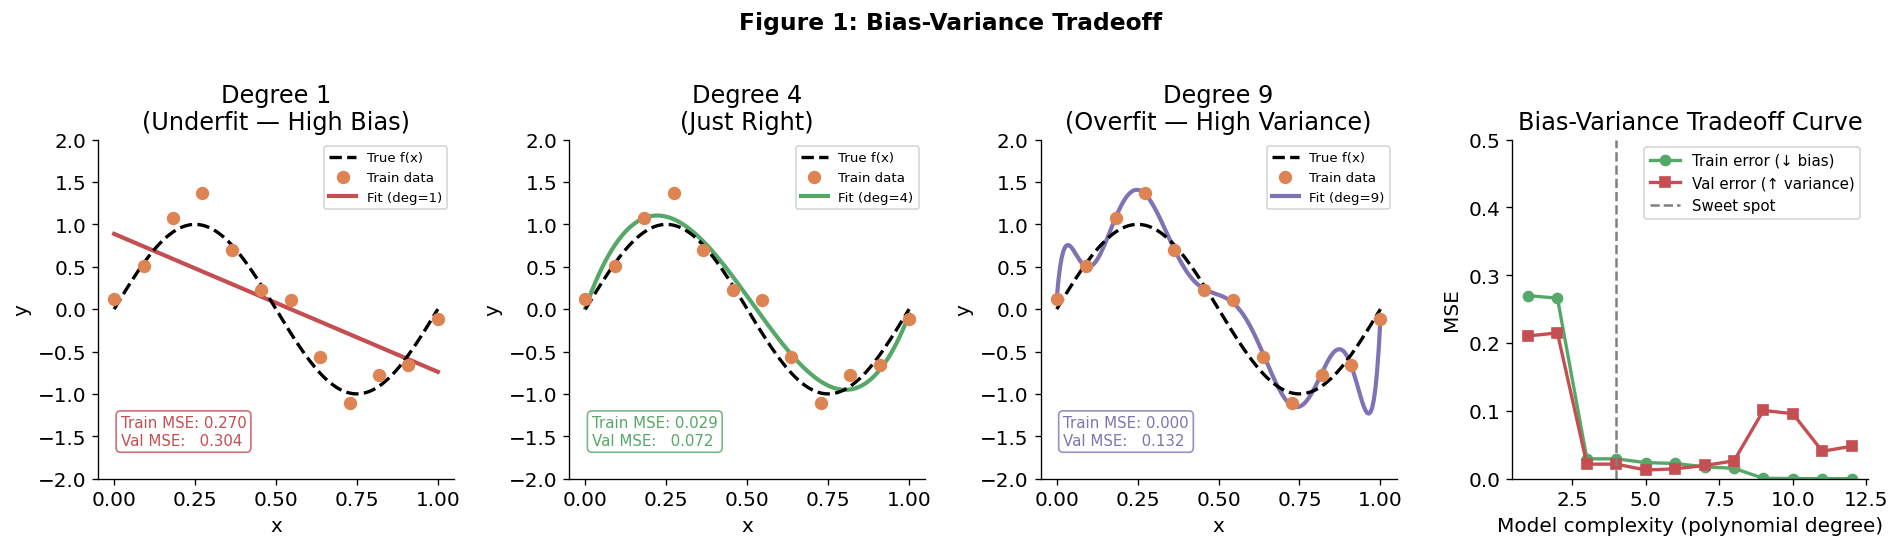

In [12]:
# Figure 1: Bias-Variance Tradeoff — polynomial fitting example
np.random.seed(42)

# True function
x_true = np.linspace(0, 1, 200)
y_true = np.sin(2 * np.pi * x_true)

# Training data (noisy)
n_train = 12
x_train = np.linspace(0, 1, n_train)
y_train = np.sin(2 * np.pi * x_train) + np.random.randn(n_train) * 0.25

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

degrees = [1, 4, 9]
titles  = ['Degree 1\n(Underfit — High Bias)', 'Degree 4\n(Just Right)',
           'Degree 9\n(Overfit — High Variance)']
colors  = ['#C44E52', '#55A868', '#8172B3']

for ax, deg, title, col in zip(axes[:3], degrees, titles, colors):
    p = np.polyfit(x_train, y_train, deg)
    y_pred = np.polyval(p, x_true)
    ax.plot(x_true, y_true, 'k--', lw=2, label='True f(x)', zorder=3)
    ax.plot(x_train, y_train, 'o', ms=7, color='#DD8452', label='Train data', zorder=4)
    ax.plot(x_true, y_pred, '-', lw=2.5, color=col, label=f'Fit (deg={deg})')
    ax.set_ylim(-2, 2); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title); ax.legend(fontsize=8)
    # Compute train & test MSE
    train_mse = np.mean((np.polyval(p, x_train) - y_train)**2)
    val_x = np.linspace(0, 1, 50)
    val_y = np.sin(2*np.pi*val_x) + np.random.randn(50)*0.25
    val_mse = np.mean((np.polyval(p, val_x) - val_y)**2)
    ax.text(0.02, -1.6, f'Train MSE: {train_mse:.3f}\nVal MSE:   {val_mse:.3f}',
            fontsize=9, color=col,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=col, alpha=0.8))

# ── Plot 4: Bias-Variance curves ──
deg_range = np.arange(1, 13)
train_errs, val_errs = [], []
for d in deg_range:
    p = np.polyfit(x_train, y_train, d)
    train_errs.append(np.mean((np.polyval(p, x_train) - y_train)**2))
    val_errs.append(np.mean((np.polyval(p, x_true) - y_true)**2))

axes[3].plot(deg_range, train_errs, 'o-', lw=2, color='#55A868', label='Train error (↓ bias)')
axes[3].plot(deg_range, val_errs,   's-', lw=2, color='#C44E52', label='Val error (↑ variance)')
axes[3].axvline(4, color='grey', ls='--', lw=1.5, label='Sweet spot')
axes[3].set_xlabel('Model complexity (polynomial degree)')
axes[3].set_ylabel('MSE'); axes[3].set_title('Bias-Variance Tradeoff Curve')
axes[3].legend(fontsize=9); axes[3].set_ylim(0, 0.5)

plt.suptitle('Figure 1: Bias-Variance Tradeoff', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 2. L2 Regularization (Weight Decay)

### Intuition: The "Rubber Band" Penalty

When a neural network trains without constraints, it tends to memorize the training data rather than discovering true underlying patterns. It does this by assigning astronomically large weights to specific, noisy features in the dataset. This results in a highly erratic function that fits the training data perfectly but fails catastrophically on unseen test data (overfitting).

**L2 Regularization** prevents this by tying a mathematical "rubber band" to every single weight in the network. 
It tells the optimizer: *"Your primary goal is to minimize the error, but if you want to use a large weight, you have to pay a massive penalty."* Because the rubber band constantly pulls the weights back toward zero, the network is forced to rely on a broad combination of many features rather than heavily weighting a few noisy outliers.

---

### The Math: Modifying the Loss Function

In L2 Regularization, we change the rules of the game before the optimizer even calculates a step. We physically add the sum of all squared weights to the loss function.

**1. The Penalized Loss Function:**
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \frac{\lambda}{2}\sum_i w_i^2$$
*(where $\lambda$ is the regularization strength hyperparameter, determining how tightly the rubber band stretches).*

**2. The New Gradient:**
When we calculate the derivative (slope) of this new loss function, the exponent from the squared term drops down, canceling fraction:
$$\frac{\partial\mathcal{L}_{\text{total}}}{\partial w_i} = \frac{\partial\mathcal{L}_{\text{data}}}{\partial w_i} + \lambda w_i$$

**3. The SGD Update Rule (The "Decay"):**
If we plug this new gradient into the standard Vanilla SGD update formula, something magical happens.
$$w_i \leftarrow w_i - \eta\left(\frac{\partial\mathcal{L}_{\text{data}}}{\partial w_i} + \lambda w_i\right)$$

If we distribute the learning rate ($\eta$) and rearrange the terms:
$$w_i \leftarrow w_i(1 - \eta\lambda) - \eta\frac{\partial\mathcal{L}_{\text{data}}}{\partial w_i}$$

Look closely at the term: **$w_i(1 - \eta\lambda)$**. 
Before the optimizer even takes a step downhill, the weight is multiplied by a number slightly less than 1 (e.g., $0.99$). This means at every single step, **the weights physically decay toward zero**. This mathematical equivalence is why L2 Regularization and Weight Decay are conceptually identical in Vanilla SGD.

---

### Geometric Intuition: The L2 Ball

Imagine plotting your loss function as topographical contour lines on a 2D map. Without regularization, the optimizer will travel to the absolute lowest point on that map, regardless of how extreme the X and Y coordinates (the weights) are.

L2 Regularization acts as a strict geographical boundary. The penalty term $\sum w_i^2$ mathematically maps to the equation of a **circle** (or a hypersphere in higher dimensions) centered exactly at the origin (0,0). 

The optimizer is forced to find a compromise: **Find the lowest possible point on the loss map that still resides inside the boundary of the L2 circle.** This prevents the weights from wandering infinitely far from the origin.

---

### Effects on the Model

| Feature | Without L2 Regularization | With L2 Regularization |
| :--- | :--- | :--- |
| **Weight Magnitude** | Can grow infinitely large | Constrained, pushed toward 0 |
| **Feature Reliance** | May rely entirely on 1 or 2 noisy features | Forces model to distribute importance across all features evenly |
| **Robustness** | Highly sensitive to input noise (jumbles) | Smooth, stable, robust predictions |
| **Loss Landscape** | Often results in narrow, sharp minima | Forces convergence in broad, flat minima (better generalization) |

---

### In Practice: The Hyperparameter $\lambda$

Tuning $\lambda$ (the `weight_decay` parameter) is incredibly impactful.
*   **$\lambda$ too small (e.g., `1e-7`):** The rubber band is too loose. The penalty is ignored, and the model overfits exactly as it would unregularized.
*   **$\lambda$ too large (e.g., `0.5`):** The rubber band is too tight. The penalty completely overpowers the actual data loss. The optimizer forces all weights to zero, causing the model to completely collapse and underfit.
*   **Standard Starting Baselines:** `1e-4` to `1e-2`.

**PyTorch Implementation:**
```python
# ✅ CORRECT for Modern Networks (Transformers, Deep CNNs)
# Decouples weight decay to work accurately with Adam
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ❌ BAD PRACTICE (The "Adam Bug")
# Adam accidentally scales down the L2 penalty on noisy weights
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ✅ CORRECT for SGD
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, weight_decay=1e-4)
```

---

### Master Interview Q&A: L2 Regularization

> **Q: Explain step-by-step why L2 Regularization is commonly referred to interchangeably as "Weight Decay."**
> 
> **A:** The term "L2 Regularization" technically refers to adding a penalty term ($\frac{\lambda}{2}w^2$) to the loss function. When you take the derivative of that penalized loss function, the resulting gradient includes a $+\lambda w$ term. When you plug that penalized gradient into the Vanilla SGD update equation and factor out the weight, you arrive at the expression $w_i(1 - \eta\lambda)$. This reveals that modifying the loss function (L2) results in the exact same mathematical operation as artificially multiplying the weight by a fraction less than 1 before taking a step. Because the weights are literally forced to "decay" functionally toward zero at every step, the historical term "Weight Decay" became synonymous with L2 Regularization.

> **Q: Does L2 Regularization force weights to become exactly `0`? Why or why not?**
> 
> **A:** No. L2 Regularization heavily penalizes *large* weights, but it struggles to force weights exactly to zero. This is because the penalty derivative is linearly proportional to the size of the weight ($\lambda w$). When a weight is massively large, the push toward zero is extremely strong. But as the weight gets microscopically close to zero, the push force also approaches zero. The penalty essentially fades away before it can crush the weight completely to `0`. (Conversely, L1 Regularization applies a constant pushing force regardless of weight size, which is why L1 creates sparse matrices with exact zeros).

> **Q: From a Bayesian perspective, what assumption does L2 Regularization implicitly make about the statistical distribution of the network's weights?**
> 
> **A:** Applying L2 Regularization is mathematically equivalent to placing a **Gaussian (Normal) Prior** centered at zero on the weights during Maximum A Posteriori (MAP) estimation. It essentially tells the model: *"Before looking at any of the data, I assume that most of the weights should be clustered very close to zero naturally, and large outlier weights are statistically highly improbable."*


c:\Users\23add\workspace\deeplearning\envNote\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1656347936822334e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\23add\workspace\deeplearning\envNote\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1656347936822334e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


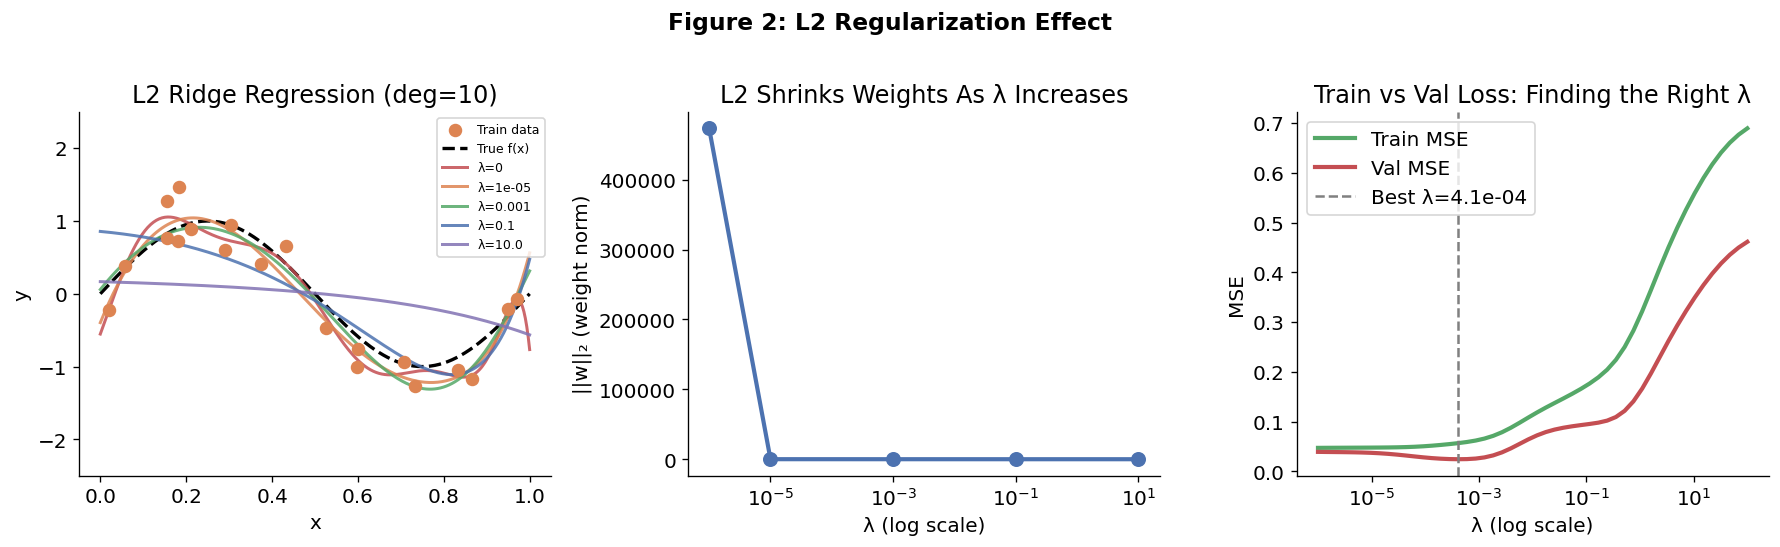

In [13]:
# Figure 2: L2 Regularization — weight shrinkage, loss landscape, train vs val
np.random.seed(42)

# Synthetic regression with overfitting
N_train, N_val = 20, 100
x_tr  = np.random.uniform(0, 1, N_train)
y_tr  = np.sin(2*np.pi*x_tr) + np.random.randn(N_train) * 0.3
x_val = np.linspace(0, 1, N_val)
y_val = np.sin(2*np.pi*x_val)
x_plot = np.linspace(0, 1, 300)

deg = 10
poly = PolynomialFeatures(deg, include_bias=True)
X_tr   = poly.fit_transform(x_tr.reshape(-1,1))
X_val  = poly.transform(x_val.reshape(-1,1))
X_plot = poly.transform(x_plot.reshape(-1,1))

lambda_vals = [0, 1e-5, 1e-3, 1e-1, 10.0]
colors_l2   = ['#C44E52','#DD8452','#55A868','#4C72B0','#8172B3']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: Fitted curves for different λ ──
axes[0].scatter(x_tr, y_tr, color='#DD8452', s=50, zorder=5, label='Train data')
axes[0].plot(x_plot, np.sin(2*np.pi*x_plot), 'k--', lw=2, label='True f(x)')
for lam, col in zip(lambda_vals, colors_l2):
    m = Ridge(alpha=lam, fit_intercept=False)
    m.fit(X_tr, y_tr)
    axes[0].plot(x_plot, m.predict(X_plot), color=col, lw=1.8, alpha=0.85,
                 label=f'λ={lam}')
axes[0].set_ylim(-2.5, 2.5); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('L2 Ridge Regression (deg=10)'); axes[0].legend(fontsize=7.5)

# ── Plot 2: Weight magnitudes vs λ ──
weight_norms = []
for lam in lambda_vals:
    m = Ridge(alpha=lam, fit_intercept=False)
    m.fit(X_tr, y_tr)
    weight_norms.append(np.linalg.norm(m.coef_))

axes[1].semilogx([max(lam, 1e-6) for lam in lambda_vals], weight_norms,
                 'o-', lw=2.5, color='#4C72B0', ms=8)
axes[1].set_xlabel('λ (log scale)'); axes[1].set_ylabel('||w||₂ (weight norm)')
axes[1].set_title('L2 Shrinks Weights As λ Increases')
axes[1].set_xscale('log')

# ── Plot 3: Train vs Val loss vs λ ──
lam_range = np.logspace(-6, 2, 50)
tr_losses, val_losses = [], []
for lam in lam_range:
    m = Ridge(alpha=lam, fit_intercept=False)
    m.fit(X_tr, y_tr)
    tr_losses.append(np.mean((m.predict(X_tr) - y_tr)**2))
    val_losses.append(np.mean((m.predict(X_val) - y_val)**2))

axes[2].semilogx(lam_range, tr_losses,  lw=2.5, color='#55A868', label='Train MSE')
axes[2].semilogx(lam_range, val_losses, lw=2.5, color='#C44E52', label='Val MSE')
best_lam = lam_range[np.argmin(val_losses)]
axes[2].axvline(best_lam, color='grey', ls='--', lw=1.5, label=f'Best λ={best_lam:.1e}')
axes[2].set_xlabel('λ (log scale)'); axes[2].set_ylabel('MSE')
axes[2].set_title('Train vs Val Loss: Finding the Right λ'); axes[2].legend()

plt.suptitle('Figure 2: L2 Regularization Effect', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 3. L1 Regularization (Lasso) — Sparsity and Feature Selection

### Intuition: The Relentless Bulldozer

In L2 Regularization, we compared the penalty to a "rubber band" attached to the origin. As a parameter gets closer to zero, the rubber band goes slack, and the pulling force becomes microscopically weak. This is why L2 shrinks weights *toward* zero but rarely reaches *exactly* zero.

**L1 Regularization** operates on a completely different physical principle. Instead of a rubber band, imagine a **relentless bulldozer** pushing the weight toward zero. 
The bulldozer doesn't care if the weight is massive (`100.0`) or microscopic (`0.001`). It applies the exact same constant, unyielding pushing force. Because this pushing force never weakens, it successfully bulldozes small, unimportant weights all the way to **exactly zero**.

**The Result:** L1 produces **sparse solutions**. If a neural network or regression model has 1,000 features, L1 might push 900 of those feature weights to exactly `0`, leaving only the 100 most critical features active. This effectively turns L1 into an automatic **Feature Selection** mechanism.

---

### The Math: Modifying the Loss Function

In L1 Regularization, instead of adding the *squared* weights to the loss function, we add the **Absolute Value** of the weights.

**1. The Penalized Loss Function:**
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda\sum_i |w_i|$$

**2. The New Gradient (The Sign Function):**
When we calculate the derivative of an absolute value $|w|$, the result is simply the `sign` of the weight ($+1$ if the weight is positive, $-1$ if the weight is negative).
$$\frac{\partial\mathcal{L}_{\text{total}}}{\partial w_i} = \frac{\partial\mathcal{L}_{\text{data}}}{\partial w_i} + \lambda \cdot \text{sign}(w_i)$$

Notice that the gradient penalty $\lambda \cdot \text{sign}(w_i)$ is a **constant magnitude**. 
*   If $w_i = 100.0$, the penalty force is $\lambda \cdot (+1)$.
*   If $w_i = 0.001$, the penalty force is still $\lambda \cdot (+1)$.
This mathematical constant force is why L1 successfully crushes small weights strictly to zero, whereas L2's proportional force ($\lambda w_i$) fades away.

---

### Geometric Intuition: The L1 Diamond

Imagine the 2D contour map of your loss function again.
*   **L2 Regularization** drew a strict geographical boundary in the shape of a **Circle**. Because a circle is perfectly smooth and round, the loss contour ellipses usually graze the edge of the circle somewhere out in the middle of a quadrant (where both $w_1$ and $w_2$ have non-zero decimal values).
*   **L1 Regularization** draws its geographical boundary in the shape of a **Diamond** (a rhombus). 

The defining feature of a diamond is its **sharp, pointy corners**, which sit exactly on the intersections of the X and Y axes. When the loss contour ellipses expand outward to touch the L1 boundary, they are geometrically overwhelmingly likely to hit one of these pointy corners first.
Because the corners sit exactly on the axes, one of the coordinates at that point is **exactly zero** (e.g., $w_1 = 0, w_2 = 1.5$). 
As you move to higher dimensions (e.g., a 1,000-dimensional hyper-diamond), the number of corners explodes, multiplying the probability that hundreds of parameters will be forced to exactly zero.

---

### L1 vs. L2: The Ultimate Comparison

| Property | L1 Regularization (Lasso) | L2 Regularization (Ridge / Weight Decay) |
| :--- | :--- | :--- |
| **Penalty Formula** | $\lambda\|w\|_1 = \lambda\sum\|w_i\|$ | $\frac{\lambda}{2}\|w\|_2^2 = \frac{\lambda}{2}\sum w_i^2$ |
| **Geometric Boundary** | Sharp Diamond (L1 ball) | Smooth Circle (L2 ball) |
| **Produces Exact Zeros?** | ✅ **Yes** (Creates Sparse models) | ❌ **No** (Creates Dense models, approaches 0) |
| **Handles Irrelevant Features** | ✅ Bulldozes them entirely | ❌ Shrinks them, but keeps treating them as partially relevant |
| **Mathematical Differentiability** | ❌ Undefined exactly at 0 (requires subgradients) | ✅ Perfectly smooth and differentiable everywhere |
| **Bayesian Prior Assumption** | **Laplace Distribution** (Heavy tail, massive spike specifically at 0) | **Gaussian Distribution** (Normal curve, smooth clustering around 0) |
| **Primary Use Cases** | Feature Selection (NLP, Genomics, highly redundant data) | General Regularization (Standard Deep Learning, Computer Vision) |

---

### Master Interview Q&A: L1 Regularization

> **Q: Geometrically, why does L1 Regularization systematically produce sparse solutions (exact zeros) while L2 Regularization essentially never does?**
> 
> **A:** It is due to the shape of the constraint region they impose on the loss landscape. The L2 penalty ($w_1^2 + w_2^2$) forms a smooth, round circle. When the elliptical contours of the data loss expand to touch this circle, they almost always touch it at a tangent point where both coordinates are non-zero decimals. The L1 penalty ($|w_1| + |w_2|$) forms a diamond with sharp corners that rest precisely on the coordinate axes. Geometrically, expanding ellipses are vastly more likely to make first contact with a protruding corner than a flat edge. Because these corners lie directly on the axes, reaching that optimal point mathematically forces one or more of the corresponding weights to be exactly zero.

> **Q: From a calculus perspective, what is the derivative of the L1 penalty at exactly $w=0$, and how is it handled in optimization algorithms?**
> 
> **A:** The absolute value function $|w|$ forms a sharp "V" shape at the origin, meaning it is mathematically **non-differentiable** precisely at $w=0$. To handle this in optimization (like Gradient Descent), we use a mathematical workaround called a **Subgradient**. The subgradient at $w=0$ is defined as any value in the range $[-\lambda, \lambda]$. In standard ML implementations, if the calculated weight update would push the weight past zero and flip its sign, the algorithm simply clamps the subgradient to 0 and permanently parks the weight exactly at $0$.

> **Q: If a weight is negative, does the absolute value penalty cause the loss to decrease? Does it still push the weight toward zero?**
> 
> **A:** No, the loss never decreases because the penalty is the *absolute value* ($|w|$). The absolute value of `-10` is `10`, meaning the penalty still adds `+10` to the total loss. To minimize this loss, the optimizer must make the absolute value smaller, which means pushing the negative weight *up* toward zero. Mathematically, the derivative of a negative weight is `-1`. When plugged into the SGD update rule ($W_{new} = W_{old} - \eta \cdot (-\lambda)$), the double negative cancels out, meaning the optimizer *adds* a positive value to the negative weight, successfully bulldozing it directly toward exactly `0`.

> **Q: If I am training a model and I know that out of my 10,000 input features, only roughly 50 of them actually determine the target variable (e.g., reading a patient's entire genome to find one specific disease marker). Should I use L1 or L2 Regularization, and why?**
> 
> **A:** You must absolutely use **L1 Regularization (Lasso)**. The scenario described is perfectly suited for Feature Selection. If you use L2, the model will assign tiny, non-zero weights to all 9,950 irrelevant features, adding immense amounts of background noise and variance to your predictions. L1 Regularization will apply a constant magnitude penalty that successfully drives the weights of the 9,950 useless features to exactly `0`, completely removing them from the equation and producing a clean, sparse model reliant only on the 50 true causal features.


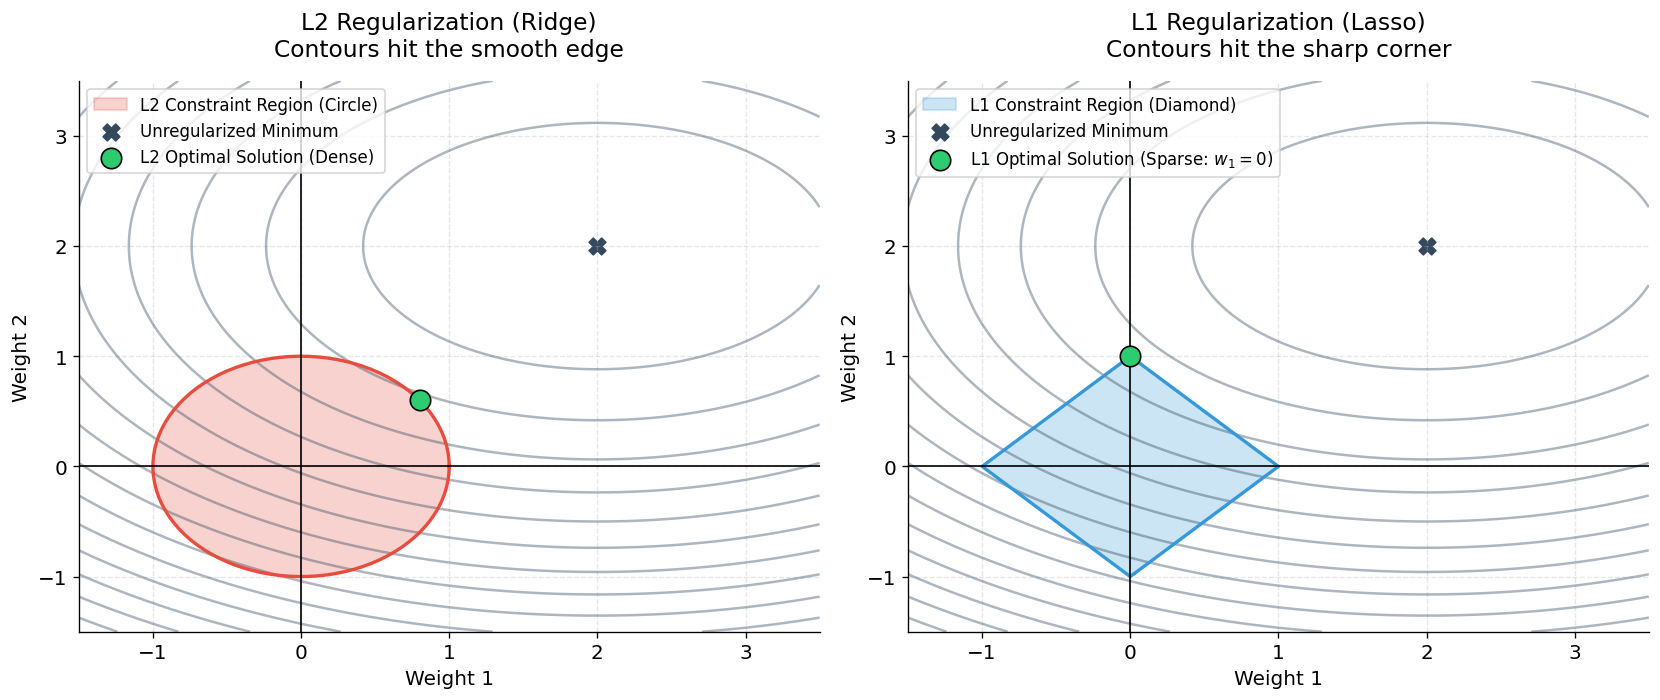

In [14]:
# Visualization of L1 (Diamond) vs L2 (Circle) Regularization Geometry
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the True Unregularized Loss function
# A simple 2D quadratic bowl centered at (w1=2, w2=2)
def compute_loss(w1, w2):
    return (w1 - 2)**2 + 2*(w2 - 2)**2

# Create the 2D grid space
w1_vals = np.linspace(-1.5, 3.5, 200)
w2_vals = np.linspace(-1.5, 3.5, 200)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
L = compute_loss(W1, W2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define plotting colors
contour_color = '#34495e'
fill_color = '#e74c3c'
optimal_pt_color = '#2ecc71'

# ----------------------------------------------------
# Plot 1: L2 Regularization (The Smooth Circle)
# ----------------------------------------------------
ax = axes[0]
# Plot the unregularized loss contours
ax.contour(W1, W2, L, levels=15, colors=contour_color, alpha=0.4, linewidths=1.5)

# L2 Constraint Boundary (w1^2 + w2^2 <= r^2)
theta = np.linspace(0, 2*np.pi, 100)
r = 1.0
l2_x = r * np.cos(theta)
l2_y = r * np.sin(theta)
ax.fill(l2_x, l2_y, color=fill_color, alpha=0.25, label='L2 Constraint Region (Circle)')
ax.plot(l2_x, l2_y, color=fill_color, linewidth=2)

# Unregularized Minimum
ax.scatter([2], [2], color=contour_color, s=100, marker='X', label='Unregularized Minimum')

# Regularized Minimum (The touch point)
# Mathematically, the tangent point is roughly at (0.8, 0.6)
ax.scatter([0.8], [0.6], color=optimal_pt_color, s=150, zorder=5, edgecolors='black', label='L2 Optimal Solution (Dense)')

ax.set_title('L2 Regularization (Ridge)\nContours hit the smooth edge', fontsize=14, pad=15)
ax.set_xlabel('Weight 1', fontsize=12)
ax.set_ylabel('Weight 2', fontsize=12)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

# ----------------------------------------------------
# Plot 2: L1 Regularization (The Sharp Diamond)
# ----------------------------------------------------
ax = axes[1]
# Plot the unregularized loss contours
ax.contour(W1, W2, L, levels=15, colors=contour_color, alpha=0.4, linewidths=1.5)

# L1 Constraint Boundary (|w1| + |w2| <= r)
r = 1.0
l1_x = [0, r, 0, -r, 0]
l1_y = [r, 0, -r, 0, r]
ax.fill(l1_x, l1_y, color='#3498db', alpha=0.25, label='L1 Constraint Region (Diamond)')
ax.plot(l1_x, l1_y, color='#3498db', linewidth=2)

# Unregularized Minimum
ax.scatter([2], [2], color=contour_color, s=100, marker='X', label='Unregularized Minimum')

# Regularized Minimum (The hit point on the corner)
# The contour naturally hits the top corner first
ax.scatter([0], [1], color=optimal_pt_color, s=150, zorder=5, edgecolors='black', label='L1 Optimal Solution (Sparse: $w_1=0$)')

ax.set_title('L1 Regularization (Lasso)\nContours hit the sharp corner', fontsize=14, pad=15)
ax.set_xlabel('Weight 1', fontsize=12)
ax.set_ylabel('Weight 2', fontsize=12)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


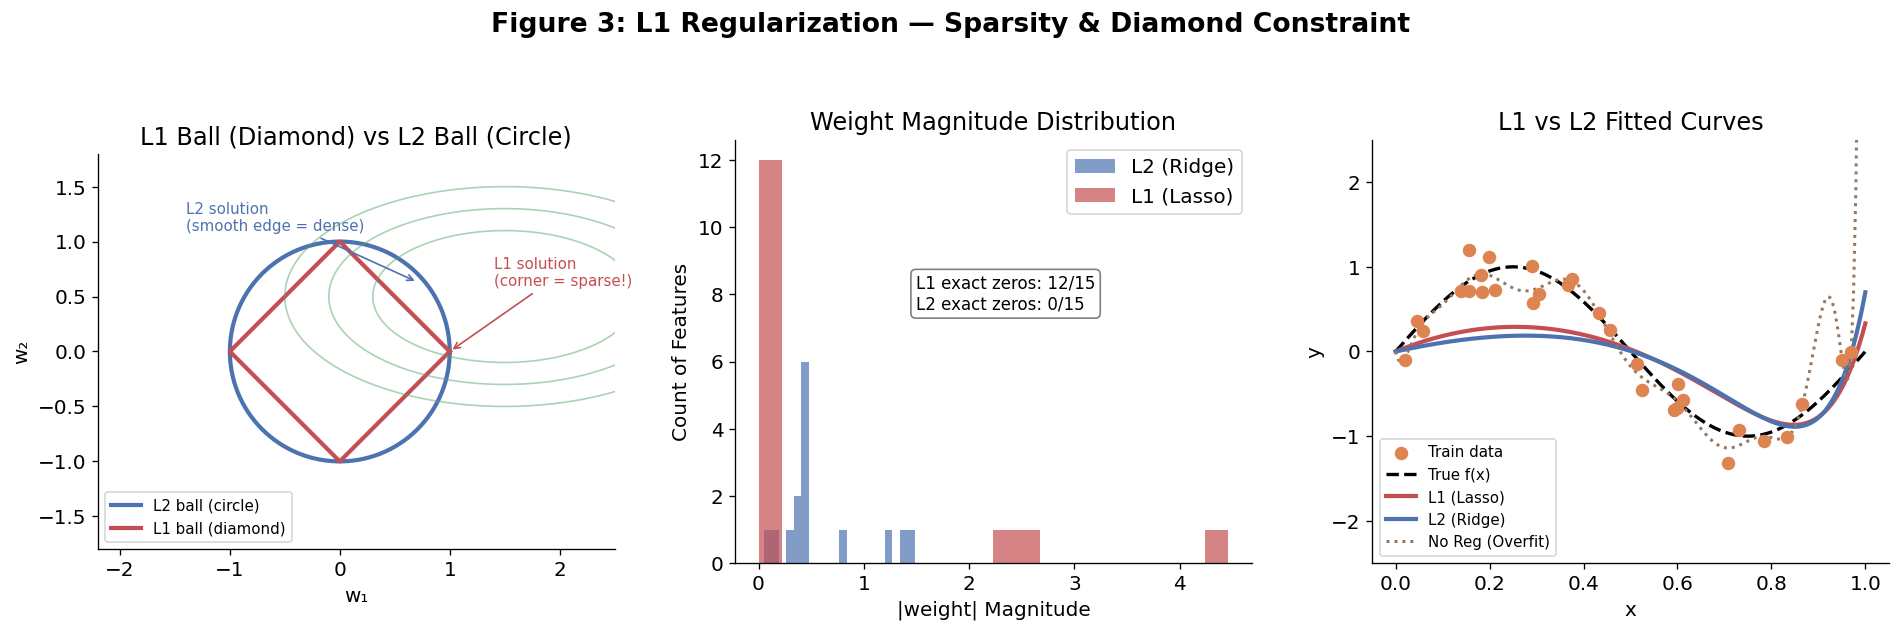

L1 (Lasso) — weights exactly zero: 12/15
L2 (Ridge) — weights exactly zero: 0/15


In [15]:
# Figure 3: L1 Regularization — sparsity, diamond constraint, L1 vs L2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)

# --- 1. Generate Synthetic Data for the Models ---
N_train = 30
x_tr = np.sort(np.random.rand(N_train))
# True function is a sine wave, added with some random noise
y_tr = np.sin(2 * np.pi * x_tr) + np.random.randn(N_train) * 0.2

# Use high-degree polynomial features (Degree 15)
# This creates 15 features for every point, giving L1 lots of useless features to zero-out!
poly = PolynomialFeatures(degree=15, include_bias=False)
X_tr = poly.fit_transform(x_tr.reshape(-1, 1))

x_plot = np.linspace(0, 1, 200)
X_plot = poly.transform(x_plot.reshape(-1, 1))

# --- 2. Setup Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: L1 vs L2 constraint regions ──
theta = np.linspace(0, 2*np.pi, 500)
# L2 ball (circle)
axes[0].plot(np.cos(theta), np.sin(theta), color='#4C72B0', lw=2.5, label='L2 ball (circle)')
# L1 ball (diamond)
axes[0].plot([1,0,-1,0,1], [0,1,0,-1,0], color='#C44E52', lw=2.5, label='L1 ball (diamond)')
# Loss contour ellipses
for r in [1.2, 1.6, 2.0]:
    ell_x = r * np.cos(theta) + 1.5
    ell_y = 0.5 * r * np.sin(theta) + 0.5
    axes[0].plot(ell_x, ell_y, color='#55A868', lw=1, alpha=0.5)
    
axes[0].annotate('L1 solution\n(corner = sparse!)', xy=(1,0), xytext=(1.4, 0.6),
                 fontsize=9, color='#C44E52',
                 arrowprops=dict(arrowstyle='->', color='#C44E52'))
axes[0].annotate('L2 solution\n(smooth edge = dense)', xy=(0.71,0.63), xytext=(-1.4, 1.1),
                 fontsize=9, color='#4C72B0',
                 arrowprops=dict(arrowstyle='->', color='#4C72B0'))

axes[0].set_xlim(-2.2, 2.5); axes[0].set_ylim(-1.8, 1.8)
axes[0].set_xlabel('w₁'); axes[0].set_ylabel('w₂')
axes[0].set_title('L1 Ball (Diamond) vs L2 Ball (Circle)')
axes[0].legend(loc='lower left', fontsize=9)
axes[0].set_aspect('equal')

# ── Plot 2: Sparsity — weight histograms ──
lam_l1, lam_l2 = 0.01, 0.01
m_l1 = Lasso(alpha=lam_l1,  fit_intercept=False, max_iter=20000) # Increased max_iter for convergence
m_l2 = Ridge(alpha=lam_l2*N_train, fit_intercept=False)
m_l1.fit(X_tr, y_tr); m_l2.fit(X_tr, y_tr)

axes[1].hist(np.abs(m_l2.coef_), bins=20, color='#4C72B0', alpha=0.7, label=f'L2 (Ridge)')
axes[1].hist(np.abs(m_l1.coef_), bins=20, color='#C44E52', alpha=0.7, label=f'L1 (Lasso)')
axes[1].set_xlabel('|weight| Magnitude'); axes[1].set_ylabel('Count of Features')
axes[1].set_title('Weight Magnitude Distribution')
axes[1].legend()

# Count how many weights were completely bulldozed to zero
n_zero_l1 = np.sum(np.abs(m_l1.coef_) < 1e-6)
n_zero_l2 = np.sum(np.abs(m_l2.coef_) < 1e-6)

# Fixed the multi-line f-string syntax error here using \n
text_box = f'L1 exact zeros: {n_zero_l1}/{len(m_l1.coef_)}\nL2 exact zeros: {n_zero_l2}/{len(m_l2.coef_)}'
axes[1].text(0.35, 0.6, text_box, transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='grey'))

# ── Plot 3: L1 fitted curves vs L2 ──
axes[2].scatter(x_tr, y_tr, color='#DD8452', s=50, zorder=5, label='Train data')
axes[2].plot(x_plot, np.sin(2*np.pi*x_plot), 'k--', lw=2, label='True f(x)')
axes[2].plot(x_plot, m_l1.predict(X_plot), color='#C44E52', lw=2.5, label=f'L1 (Lasso)')
axes[2].plot(x_plot, m_l2.predict(X_plot), color='#4C72B0', lw=2.5, label=f'L2 (Ridge)')

no_reg = LinearRegression(fit_intercept=False).fit(X_tr, y_tr)
axes[2].plot(x_plot, no_reg.predict(X_plot), color='#937860', lw=1.8, ls=':', label='No Reg (Overfit)')

axes[2].set_ylim(-2.5, 2.5); axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
axes[2].set_title('L1 vs L2 Fitted Curves')
axes[2].legend(fontsize=9, loc='lower left')

plt.suptitle('Figure 3: L1 Regularization — Sparsity & Diamond Constraint', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print(f"L1 (Lasso) — weights exactly zero: {n_zero_l1}/{len(m_l1.coef_)}")
print(f"L2 (Ridge) — weights exactly zero: {n_zero_l2}/{len(m_l2.coef_)}")


## 4. Elastic Net — The Best of Both Worlds

### Intuition: The "Grouped" Selection Problem

To understand why Elastic Net exists, we have to look at the fatal flaw of pure L1 Regularization (Lasso). 
L1 is fantastic at bulldozing useless features to zero. However, when it encounters **highly correlated features** (e.g., "Height in Inches" and "Height in Centimeters", or words like "Good", "Great", and "Excellent" in an NLP task), L1 becomes unstable. 

Because L1 wants to minimize the absolute sum of weights, if it sees 3 features that all provide the exact same information, **it will arbitrarily pick one feature, keep its weight, and ruthlessly crush the other two to exactly zero.** 
This is dangerous because you lose interpretability, and if the one feature it picked happens to be slightly noisy in the test set, your whole model breaks.

**Elastic Net** fixes this by mathematically combining both penalties. 
*   It uses **L1** to bulldoze the completely useless features to zero.
*   It uses **L2** to apply a "rubber band" effect across correlated groups. Instead of picking one feature and killing the others, L2 forces the model to distribute the weight smoothly across the entire correlated group.

---

### The Math: Combining the Penalties

Elastic Net is simply the linear combination of the L1 and L2 penalty terms, controlled by a mixing ratio hyperparameter $\alpha$ (often called `l1_ratio`).

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda\left[ \alpha\sum_i|w_i| + \frac{(1-\alpha)}{2}\sum_iw_i^2 \right]$$

*   If $\alpha = 0$: You get pure L2 Regularization (Ridge).
*   If $\alpha = 1$: You get pure L1 Regularization (Lasso).
*   If $0 < \alpha < 1$: You get Elastic Net. (e.g., $\alpha = 0.5$ means a 50/50 split of the bulldozer and the rubber band).

**Geometric Interpretation:**
If L2 is a circular boundary and L1 is a sharp diamond boundary, you can imagine Elastic Net as a **"rounded diamond."** It still has pointy tips on the axes (meaning it can still produce exact zeros and sparsity), but the edges bow outward like a circle (giving it the grouping stability of L2).

---

### Why Elastic Net is Rare in Deep Learning

While Elastic Net is a powerhouse for linear regression and classical machine learning (especially in bioinformatics and statistics), you will almost never see it used inside deep neural networks.

1.  **Gradient Discontinuity:** The L1 component of Elastic Net requires subgradients because it is non-differentiable at exactly $0$. While autograd systems (like in PyTorch) *can* handle this, it adds computational overhead and instability to the million-parameter backpropagation process.
2.  **Better Alternatives Exist:** In the modern Deep Learning era, we have discovered significantly better ways to regularize complex, non-linear networks:
    *   **L2 Weight Decay** (built into AdamW) is the undisputed standard for parameter shrinkage.
    *   **Dropout** is astronomically more effective at preventing feature co-adaptation than mathematical weight penalties.
    *   **Batch Normalization** provides strong implicit regularization as a byproduct of stabilizing the forward pass.

---

### Master Interview Q&A: Elastic Net

> **Q: Describe a specific dataset scenario where pure L1 (Lasso) would fail or be suboptimal, and explain how Elastic Net solves the problem.**
> 
> **A:** Pure L1 struggles heavily with multi-collinearity (highly correlated features). For example, if you are predicting housing prices and have 5 features that all represent the size of the house (Square Footage, Number of Rooms, Plot Size, etc.), L1 will arbitrarily assign a non-zero weight to just one of those features and crush the other 4 to exactly zero. This makes the model highly brittle to noise in that single feature. Elastic Net solves this by introducing the L2 penalty, which strictly penalizes large individual weights. Because $(0.5^2 + 0.5^2)$ is less than $(1.0^2 + 0^2)$, the L2 component forces the network to distribute the weight evenly across all the correlated features (the "Grouping Effect"), while the L1 component still allows it to drop completely irrelevant features (like house color) to zero.

> **Q: Since L1 imposes sparsity, and we know deep neural networks are massively overparameterized, why don't we heavily use Elastic Net or L1 to drastically reduce the size of neural networks during training?**
> 
> **A:** Historically, using L1 to induce exact sparsity during gradient descent in deep networks is computationally unstable due to the non-differentiable point at zero ($|w|$). More importantly, the hardware used to train networks (GPUs/TPUs) is optimized for dense matrix multiplications. Having a sparse matrix (filled with exact zeros) doesn't actually speed up a standard GPU unless the sparsity is highly structured, meaning the "computational" benefit of L1 is lost. Instead of L1, modern deep learning achieves regularization and prevents co-adaptation using architectural techniques like **Dropout** and **Data Augmentation**, relying safely on pure decoupled L2 (AdamW) for weight shrinkage.



c:\Users\23add\workspace\deeplearning\envNote\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.451e-02, tolerance: 1.591e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\23add\workspace\deeplearning\envNote\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.354e-02, tolerance: 1.591e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\23add\workspace\deeplearning\envNote\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consi

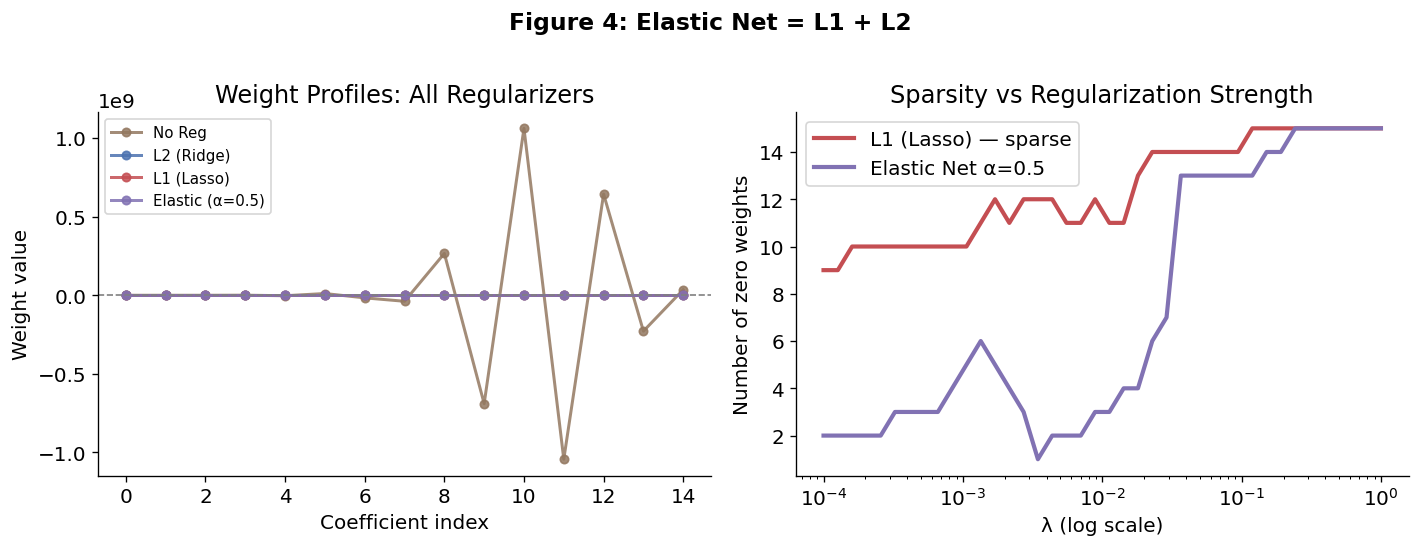

In [16]:
# Figure 4: L1, L2, Elastic Net comparison
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Plot 1: Weight profiles for different regularizers ──
lam = 0.005
models = {
    'No Reg':          LinearRegression(fit_intercept=False).fit(X_tr, y_tr),
    'L2 (Ridge)':      Ridge(alpha=lam*N_train, fit_intercept=False).fit(X_tr, y_tr),
    'L1 (Lasso)':      Lasso(alpha=lam, fit_intercept=False, max_iter=5000).fit(X_tr, y_tr),
    'Elastic (α=0.5)': ElasticNet(alpha=lam, l1_ratio=0.5, fit_intercept=False, max_iter=5000).fit(X_tr, y_tr),
}
colors_en = ['#937860','#4C72B0','#C44E52','#8172B3']
x_idx = np.arange(len(list(models.values())[0].coef_))

for (name, m), col in zip(models.items(), colors_en):
    axes[0].plot(x_idx, m.coef_, 'o-', ms=5, lw=1.8, color=col, label=name, alpha=0.85)
axes[0].axhline(0, color='grey', ls='--', lw=1)
axes[0].set_xlabel('Coefficient index'); axes[0].set_ylabel('Weight value')
axes[0].set_title('Weight Profiles: All Regularizers'); axes[0].legend(fontsize=9)

# ── Plot 2: Sparsity vs λ ──
lam_range = np.logspace(-4, 0, 40)
sparsity_l1, sparsity_en = [], []
for lam in lam_range:
    ml1 = Lasso(alpha=lam, fit_intercept=False, max_iter=5000).fit(X_tr, y_tr)
    men = ElasticNet(alpha=lam, l1_ratio=0.5, fit_intercept=False, max_iter=5000).fit(X_tr, y_tr)
    sparsity_l1.append(np.sum(np.abs(ml1.coef_) < 1e-6))
    sparsity_en.append(np.sum(np.abs(men.coef_) < 1e-6))

axes[1].semilogx(lam_range, sparsity_l1, lw=2.5, color='#C44E52', label='L1 (Lasso) — sparse')
axes[1].semilogx(lam_range, sparsity_en, lw=2.5, color='#8172B3', label='Elastic Net α=0.5')
axes[1].set_xlabel('λ (log scale)'); axes[1].set_ylabel('Number of zero weights')
axes[1].set_title('Sparsity vs Regularization Strength'); axes[1].legend()

plt.suptitle('Figure 4: Elastic Net = L1 + L2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Dropout — Preventing Feature Co-adaptation

### Intuition: The "Bus Factor" and Star Employees

Imagine a company where every major engineering decision relies on a single "10x star employee." If that employee gets sick, or wins the lottery and quits (the classic "bus factor"), the entire company grinds to a halt. The company is fundamentally fragile because everyone else learned to just sit back and let the star employee do the heavy lifting.

A resilient company cross-trains its employees. It forces different teams to handle multiple tasks so that if anyone is randomly absent, the rest of the team can easily compensate and the product still ships.

**Dropout** does exactly this to a neural network. It prevents neurons from acting like lazy employees relying too heavily on the output of a specific "star" neuron (a phenomenon mathematically called **co-adaptation**). By randomly "turning off" a percentage of neurons during every single training step, the network is forced to learn highly redundant representations. The network learns it cannot trust any single feature to always be there, so it must spread the "knowledge" out across the entire layer.

---

### The Mechanics: Random Silencing

During the forward pass of training, Dropout creates a random "mask" for the layer.
For every single neuron, it flips a biased coin:
*   With a probability $p$ (e.g., 0.5), it completely zeroes out that neuron's activation.
*   With a probability $(1-p)$, it leaves the neuron completely alone.

Because the neuron's output is zero, it essentially ceases to exist for that specific training step. It contributes nothing to the final prediction, and during backpropagation, it **receives a gradient calculated as precisely zero**.

**The Catch:** This random mask is completely re-rolled at every single batch. The network never drops the same fixed subset of neurons; the layout of the "absent employees" is constantly shifting.

---

### The Hidden Mathematical Secret: Inverted Dropout

*(This is one of the most critical concepts missing from most basic tutorials).*

If you drop out 50% of the neurons during training, the next layer is only receiving half as much raw input signal as it normally would.
At **test time (inference)**, we want to use the full, unbridled power of the network, so we **turn Dropout completely OFF** (all neurons are 100% active).
However, if the network suddenly receives 100% of the signal at test time after training its weights to expect only 50%, the activations will be twice as massive as expected. The **expected activation at test time $\neq$ expected activation at train time**, which mathematically breaks the model's predictions.

There are two ways to solve this Train vs. Test discrepancy:

#### Solution 1: Vanilla Dropout (The Old Way)
*   **Train:** Randomly drop neurons with probability $p$.
*   **Test:** Keep all neurons active, but **multiply all activations by $(1-p)$** to artificially scale them down to match the training expectation.
*   **The Problem:** Modifying millions of physical weights or activations dynamically at test time adds unnecessary computational overhead to inference. Worse, it requires a completely separate code path for testing, making it easy to forget.

#### Solution 2: Inverted Dropout (The Modern PyTorch/TensorFlow Standard)
*   **Train:** Drop neurons AND instantly **divide the surviving activations by $(1-p)$** to compensate immediately.
*   **Test:** Do absolutely nothing.

$$\tilde{a}^{(l)} = \frac{r^{(l)} \odot a^{(l)}}{1 - p}$$

By artificially pumping up the signal of the surviving neurons during training, it ensures that the **expected sum of the activations remains exactly the same** between training and testing: $\mathbb{E}[\tilde{a}] = (1-p) \cdot \frac{a}{1-p} = a$.

This allows the network to run at maximum optimal speed during test time with zero modifications or scaling required!

---

### Critical Practice: `model.train()` vs `model.eval()`

Because modern frameworks use Inverted Dropout, the layer inherently behaves differently depending on what phase of the machine learning pipeline you are in.

```python
model.train()   # Dropout IS physically active (neurons are randomly dropped and scaled)
model.eval()    # Dropout IS completely disabled (all neurons pass through untouched)
```

**You must always call `model.eval()` before running inference!**
If you forget this, your model will continue randomly dropping neurons while trying to make live predictions. Your outputs will be highly stochastic, systematically incorrect, and will fluctuate wildly every time you pass the exact same input into the model.

---

### The Ensemble Interpretation

A neural network with $n$ neurons has $2^n$ uniquely different possible subnetworks (every possible combination of neurons being randomly on or off).
Because the dropout mask is totally random at every step, you are effectively training millions of uniquely tiny, "thinned" neural networks that all share the exact same weights.

At test time, when you turn Dropout off and use the full network, you are mathematically approximating an **Ensemble Average** of all $2^n$ subnetworks computing their predictions at the exact same time. Ensembling is a statistically proven technique for massive variance reduction, which is exactly why Dropout prevents overfitting so universally well.

---

### Dropout Rates by Architecture

| Layer Type | Typical Dropout Rate ($p$) | Why? |
| :--- | :--- | :--- |
| **Fully Connected (Hidden)** | 0.5 | Dense parameters easily memorize data and highly co-adapt. |
| **Fully Connected (Input)** | 0.1 – 0.2 | You never want to destroy too much of the raw, untouched input signal. |
| **Convolutional Layers** | 0.0 – 0.2 (Or None) | CNNs already have very few parameters (shared weights). Furthermore, neighboring pixels are highly correlated, so dropping a random pixel just forces the network to look at the pixel immediately next to it (it doesn't actually stop co-adaptation). |
| **Transformer Attention** | 0.1 | Used to lightly regularize the wildly flexible attention distribution matrices. |

---

### Master Interview Q&A: Dropout

> **Q: Explain the mechanical concept of "Inverted Dropout" and specifically why modern deep learning frameworks use it instead of standard historical Dropout.**
> 
> **A:** When using Dropout, you purposefully zero out a $p$ fraction of neurons during training, meaning the expected sum of the forward activations shrinks by $(1-p)$. Historically, in "Standard Dropout," you fixed this discrepancy at test time by artificially scaling down the network's trained weights by $(1-p)$ before predicting. However, modifying millions of physical weights dynamically at test time adds unnecessary computational overhead to inference. "Inverted Dropout" solves this by shifting the math to the *training* phase. After randomly dropping neurons, the remaining active neurons are immediately scaled *up* by a factor of $\frac{1}{1-p}$. This ensures the expected activation value stays perfectly constant identically across both phases, allowing the network to run at maximum optimal speed with zero code or weight modifications during inference.

> **Q: Why is it a catastrophic bug to forget to call `model.eval()` before running inference on test data?**
> 
> **A:** Because Dropout layers (and Batch Normalization layers) behave fundamentally differently at train time versus test time. If you leave the model in `.train()` mode, the Dropout layers will continue to randomly zero out neurons during inference. This means your network's predictions will be completely non-deterministic (stochastic) and systematically incorrect, as you are randomly destroying features instead of using the fully trained ensemble effect. Calling `.eval()` locks the Dropout layer so it passes all neurons through 100% untouched.

> **Q: Why is standard Dropout rarely used, or fundamentally ineffective, when applied directly to Convolutional Neural Network (CNN) feature maps?**
> 
> **A:** Dropout explicitly works by forcing neurons to learn independent features instead of relying on the presence of other neurons (co-adaptation). In a CNN feature map, spatial adjacent pixels are overwhelmingly heavily correlated (e.g., if you apply standard dropout to one pixel representing a dog's ear, the network easily infers the exact same dog's ear pattern from the identical pixel directly adjacent to it). Standard dropout completely fails to break this correlation. To reliably regularize a CNN, you must use **Spatial Dropout (Dropout2D)**, which drops out entire continuous 2D feature maps (entire channels) at random, forcing the network to look for completely different kinds of features rather than just looking 1 pixel to the left.

> **Q: Explain the exact mathematical and computational differences between training one huge network with Dropout versus training a True Ensemble of 10 distinctly smaller networks.**
> 
> **A:** While Dropout mathematically approximates an ensemble of $2^n$ subnetworks, there is one massive architectural difference: **Weight Sharing**. In a true ensemble of 10 independent networks, every single parameter matrix is instantiated and trained independently from scratch, literally requiring 10x the GPU memory and 10x the computational FLOPs. In Dropout, all $2^n$ theoretical subnetworks physically share the exact same underlying weight architecture in memory. Dropout provides the massive statistical variance-reduction benefits of an impossibly huge ensemble while maintaining the exact computational footprint of training a single network.

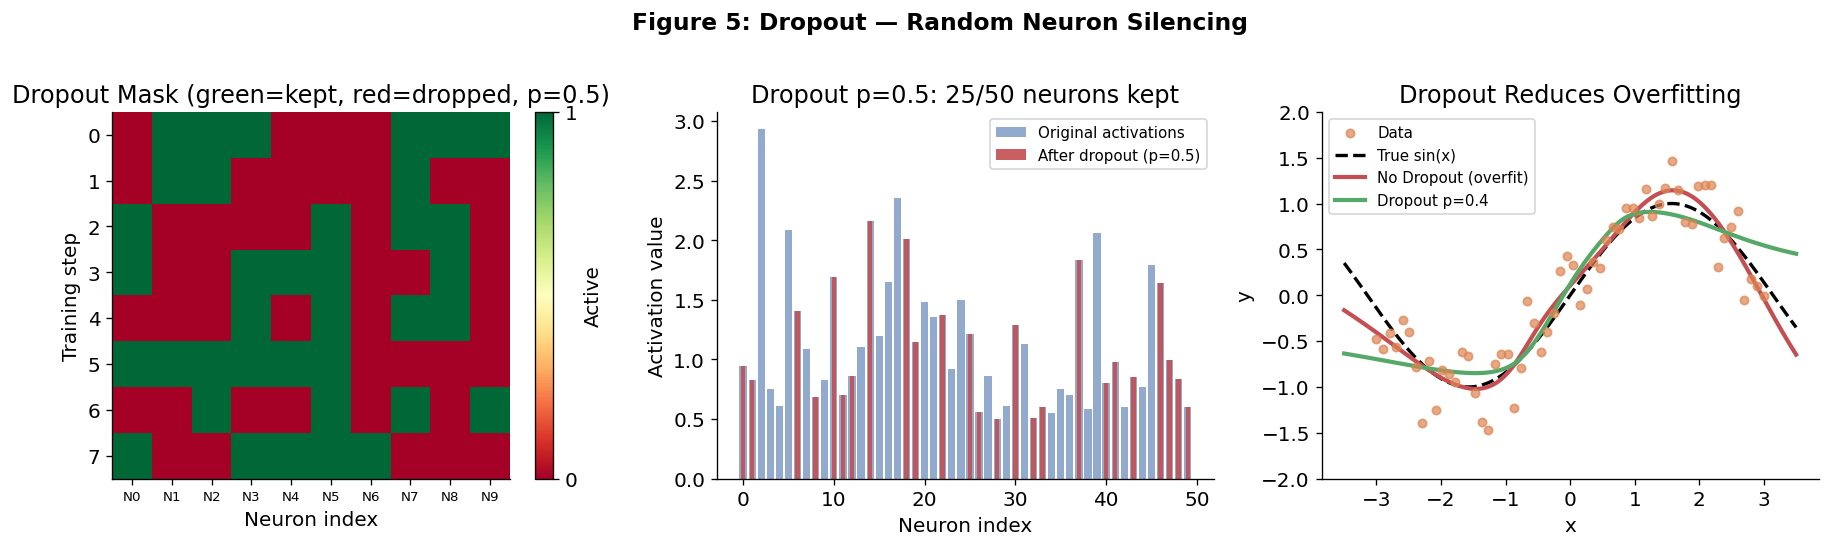

In [17]:
# Figure 5: Dropout — masking demo, ensemble interpretation
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: Dropout mask visualisation ──
n_neurons, n_passes = 10, 8
masks = np.random.binomial(1, 0.5, (n_passes, n_neurons))
im = axes[0].imshow(masks, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[0].set_xlabel('Neuron index'); axes[0].set_ylabel('Training step')
axes[0].set_title('Dropout Mask (green=kept, red=dropped, p=0.5)')
axes[0].set_xticks(range(n_neurons)); axes[0].set_yticks(range(n_passes))
axes[0].set_xticklabels([f'N{i}' for i in range(n_neurons)], fontsize=8)
plt.colorbar(im, ax=axes[0], ticks=[0,1], label='Active')

# ── Plot 2: Effect of dropout on activation values ──
np.random.seed(5)
activations = np.abs(np.random.randn(50)) + 0.5
p_drop = 0.5
mask = np.random.binomial(1, 1-p_drop, 50)
dropped = activations * mask

x_idx = np.arange(50)
axes[1].bar(x_idx, activations, color='#4C72B0', alpha=0.6, label='Original activations')
axes[1].bar(x_idx, dropped,     color='#C44E52', alpha=0.9, label=f'After dropout (p={p_drop})',
            width=0.5)
axes[1].set_xlabel('Neuron index'); axes[1].set_ylabel('Activation value')
axes[1].set_title(f'Dropout p={p_drop}: {mask.sum()}/50 neurons kept')
axes[1].legend(fontsize=9)

# ── Plot 3: Overfitting with vs without dropout ──
torch.manual_seed(0)
N = 60
X_data = torch.linspace(-3, 3, N).unsqueeze(1)
y_data = torch.sin(X_data) + 0.3 * torch.randn_like(X_data)

class Net(nn.Module):
    def __init__(self, use_dropout=False, p=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Dropout(p) if use_dropout else nn.Identity(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Dropout(p) if use_dropout else nn.Identity(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

def train_net(use_dropout, epochs=1500):
    net = Net(use_dropout=use_dropout)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    for _ in range(epochs):
        net.train()
        opt.zero_grad()
        loss = nn.MSELoss()(net(X_data), y_data)
        loss.backward()
        opt.step()
    return net

net_nodrop = train_net(False)
net_drop   = train_net(True)

x_test = torch.linspace(-3.5, 3.5, 200).unsqueeze(1)
net_nodrop.eval(); net_drop.eval()
with torch.no_grad():
    y_nodrop = net_nodrop(x_test).numpy()
    y_drop   = net_drop(x_test).numpy()

axes[2].scatter(X_data.numpy(), y_data.numpy(), color='#DD8452', s=25, zorder=4, label='Data', alpha=0.7)
axes[2].plot(x_test.numpy(), np.sin(x_test.numpy()), 'k--', lw=2, label='True sin(x)')
axes[2].plot(x_test.numpy(), y_nodrop, color='#C44E52', lw=2.5, label='No Dropout (overfit)')
axes[2].plot(x_test.numpy(), y_drop,   color='#55A868', lw=2.5, label='Dropout p=0.4')
axes[2].set_ylim(-2, 2); axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
axes[2].set_title('Dropout Reduces Overfitting'); axes[2].legend(fontsize=9)

plt.suptitle('Figure 5: Dropout — Random Neuron Silencing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


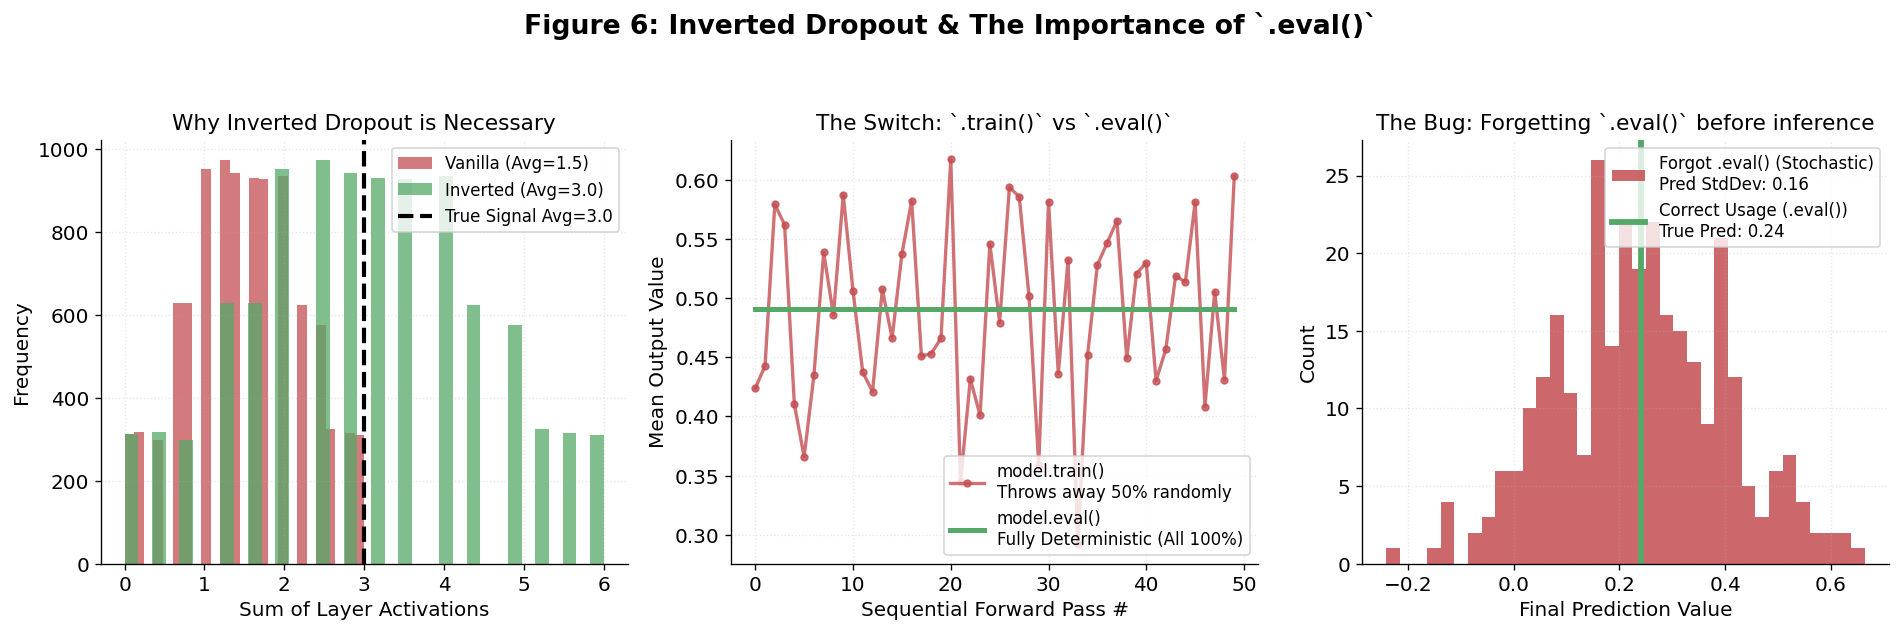

🚨 CRITICAL PYTORCH RULE 🚨
---------------------------
  model.train()  → Use during Training  (Random Neurons Dropped & Scaled)
  model.eval()   → Use during Inference (Math is locked, 100% Deterministic)
  Forgetting model.eval() is one of the most common PyTorch bugs!


In [20]:
# Figure 6: Inverted Dropout — Train vs Test Discrepancy & model.eval()
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Ensure fully reproducible results
torch.manual_seed(42)
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'vanilla': '#C44E52', 'inverted': '#55A868', 'true': '#34495e'}

# ------------------------------------------------------------------
# ── Plot 1: Vanilla vs. Inverted Dropout Mathematical Expectations ──
# ------------------------------------------------------------------
p = 0.5
# 5 sample activations
activations = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
true_mean = activations.mean().item() # Expected is 3.0
N_samples = 10000

vanilla_train, inverted_train = [], []
for _ in range(N_samples):
    mask = (torch.rand_like(activations) > p).float()
    
    # Vanilla: Just drop the neurons (unscaled)
    vanilla_train.append((mask * activations).mean().item())
    
    # Inverted: Drop the neurons AND scale up by (1-p)
    inverted_train.append((mask * activations / (1 - p)).mean().item())

axes[0].hist(vanilla_train, bins=25, color=colors['vanilla'], alpha=0.75,
             label=f"Vanilla (Avg={np.mean(vanilla_train):.1f})")
axes[0].hist(inverted_train, bins=35, color=colors['inverted'], alpha=0.75,
             label=f"Inverted (Avg={np.mean(inverted_train):.1f})")

axes[0].axvline(true_mean, color='black', ls='--', lw=2.5, label=f"True Signal Avg={true_mean:.1f}")

axes[0].set_xlabel('Sum of Layer Activations'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Why Inverted Dropout is Necessary', fontsize=13)
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3, ls=':')

# ------------------------------------------------------------------
# ── Plot 2: model.train() vs model.eval() Behavior ──
# ------------------------------------------------------------------
net = nn.Sequential(nn.Linear(5, 5), nn.Dropout(p=0.5))
x_in = torch.ones(10, 5) # Batch of 10

# Train mode: stochastic forward passes
net.train()
outputs_train = [net(x_in).detach().mean().item() for _ in range(50)]

# Eval mode: deterministic forward passes (all neurons active)
net.eval()
outputs_eval  = [net(x_in).detach().mean().item() for _ in range(50)]

axes[1].plot(outputs_train, color=colors['vanilla'], lw=2, marker='o', ms=4, alpha=0.8,
             label='model.train()\nThrows away 50% randomly')
axes[1].plot(outputs_eval, color=colors['inverted'], lw=3, label='model.eval()\nFully Deterministic (All 100%)')

axes[1].set_xlabel('Sequential Forward Pass #'); axes[1].set_ylabel('Mean Output Value')
axes[1].set_title('The Switch: `.train()` vs `.eval()`', fontsize=13)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3, ls=':')

# ------------------------------------------------------------------
# ── Plot 3: The Classic Bug (Forgetting .eval() at test time) ──
# ------------------------------------------------------------------
# A moderately deep network where dropping out heavily impacts the end prediction
class BuggyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 1)
        )
    def forward(self, x): 
        return self.net(x)

bignet = BuggyNet()
x_test = torch.randn(1, 10)

# Simulate User Forgetting .eval()
bignet.train()
stochastic_predictions = [bignet(x_test).item() for _ in range(300)]

# Simulate Correct Inference
bignet.eval()
with torch.no_grad():
    correct_prediction = bignet(x_test).item()

axes[2].hist(stochastic_predictions, bins=35, color=colors['vanilla'], alpha=0.85,
             label=f'Forgot .eval() (Stochastic)\nPred StdDev: {np.std(stochastic_predictions):.2f}')
axes[2].axvline(correct_prediction, color=colors['inverted'], lw=3.5,
                label=f'Correct Usage (.eval())\nTrue Pred: {correct_prediction:.2f}')

axes[2].set_xlabel('Final Prediction Value'); axes[2].set_ylabel('Count')
axes[2].set_title('The Bug: Forgetting `.eval()` before inference', fontsize=13)
axes[2].legend(loc='upper right', fontsize=10)
axes[2].grid(True, alpha=0.3, ls=':')

plt.suptitle('Figure 6: Inverted Dropout & The Importance of `.eval()`', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("🚨 CRITICAL PYTORCH RULE 🚨")
print("---------------------------")
print("  model.train()  → Use during Training  (Random Neurons Dropped & Scaled)")
print("  model.eval()   → Use during Inference (Math is locked, 100% Deterministic)")
print("  Forgetting model.eval() is one of the most common PyTorch bugs!")


## 7. Early Stopping — The Ultimate "Free" Regularizer

### Intuition: The "Cramming" Student

Imagine a student studying for a comprehensive final exam. They are given a stack of practice tests (the Training Set).
*   During the first few hours of studying, they are learning actual concepts (math rules, historical dates). Their score on the practice tests goes up, and if you handed them a brand new exam (the Validation Set), their score would go up there too.
*   However, if they stay up for 72 hours straight frantically re-taking the exact same practice tests over and over, they will eventually stop learning overarching concepts and simply **memorize the specific answer key** for that one practice test (e.g., "The answer to question 4 is always C"). 

Their practice test score will hit 100%, but if you hand them a brand new exam (Validation Set), they will fail miserably because they just memorized the noise of the practice test.

**Early Stopping** is the teacher walking into the room and ripping the practice tests out of the student's hands the exact second their performance on the *new* exam starts to drop. 

---

### The U-Shaped Validation Curve

This concept ties perfectly back into the **Bias-Variance Tradeoff**. 

As training progresses (Epochs increase), the model's capacity to fit the data increases.
1.  **Underfitting Zone (High Bias):** Training loss is high. Validation loss is high. The model is still learning the macro-patterns.
2.  **The Sweet Spot (Optimal Generalization):** Training loss is low. Validation loss is at its absolute minimum. The model has learned the true patterns but hasn't yet started memorizing noise.
3.  **Overfitting Zone (High Variance):** Training loss conceptually approaches zero. But **Validation loss begins to rise**, forming the right side of a U-shape. The model is now actively memorizing the irreducible noise ($\epsilon$) of the training set.

Early Stopping monitors the Validation Loss at the end of every epoch. The moment the Validation Loss begins to climb back up the U-shape, it halts training.

---

### The Algorithm (With Patience)

Because neural network training is highly stochastic (due to random mini-batches and Dropout), the validation loss curve is almost never perfectly smooth. It will frequently bounce up for an epoch or two before continuing back down. 

If we stopped the moment it ticked up once, we would stop way too early. To fix this, we introduce **Patience**. 

```python
best_val_loss = infinity
patience = 5  # How many epochs to wait before giving up
current_patience_count = 0

for epoch in range(max_epochs):
    train_one_epoch()
    current_val_loss = evaluate_on_validation_set()

    # Did we hit a new all-time low?
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss     # Update the record
        current_patience_count = 0           # Reset the patience timer
        save_model_weights("best_model.pt")  # 💾 SAVE THE WEIGHTS!
    else:
        # We didn't improve. Tick the patience timer.
        current_patience_count += 1
    
    # Did we run out of patience?
    if current_patience_count >= patience:
        print("Early Stopping triggered! Restoring best weights.")
        break

# The most critical step!
load_model_weights("best_model.pt")
```

### Critical Concept: Restoring Best Weights

The biggest mistake beginners make is triggering Early Stopping and then deploying the model as it exists at that exact moment.

If your patience is `10`, that means the model just spent the last 10 epochs actively getting worse (overfitting) before the algorithm finally gave up and halted. The model at the moment of stopping is heavily overfit! **You must always save the model weights specifically at the epoch that achieved the `best_val_loss`, and reload those exact weights before deploying.**

---

### Master Interview Q&A: Early Stopping

> **Q: Explain how Early Stopping acts as an implicit mathematical equivalent to L2 Regularization (Weight Decay).**
> 
> **A:** When a neural network is initialized, its weights start very close to zero. During training, gradient descent dynamically grows these weights to fit the data. Because L2 Regularization explicitly penalizes large weights, it acts as a constraint that forces the weights to stay smaller than they naturally would want to be. Early Stopping achieves the exact same physical outcome. By forcefully hard-stopping the gradient descent process before it reaches its mathematical limit (convergence), you physically prevent the weights from having enough time (num_epochs) to grow astronomically large to memorize the training data. Both techniques constrain the L2 norm of the network's weights; one does it via the loss function penalty, and the other does it via time restriction.

> **Q: What is the "Patience" hyperparameter, and what are the trade-offs of setting it too high versus too low?**
> 
> **A:** Patience dictates exactly how many consecutive epochs the validation loss is allowed to degrade (or flatline) before training is forcefully terminated. In stochastic training (like SGD), the loss landscape is noisy. If Patience is `0`, training will terminate the instant a single bad mini-batch causes a temporary spike in validation loss, massively underfitting the model. If Patience is too high (e.g., `100`), the model will spend an astronomical amount of wasted GPU compute blindly wandering through the overfitting regime long after the true minimum was passed. Standard values usually sit between `10` and `30` depending on the learning rate schedule.

> **Q: Advanced Topic: Have you heard of the phenomenon of "Double Descent"? How does it challenge the classical U-shaped Validation curve assumption that Early Stopping relies on?**
> 
> **A:** Classical statistical theory dictates the Bias-Variance tradeoff forms a strict "U-shape" where validation loss goes down, hits a minimum, and goes back up due to overfitting. Early Stopping assumes the bottom of this U-shape is the optimal model. 
> However, modern deep learning researchers discovered "Double Descent." If you keep training a historically over-parameterized model *past* the point of overfitting (where validation loss goes back up), something magical happens: the validation loss eventually peaks and then violently descends a *second* time, often reaching a better absolute minimum than the first valley. The model essentially gathers so much capacity that it smoothly interpolates the data. Traditional Early Stopping is functionally blind to Double Descent because it will terminate training during the initial overfitting hump, potentially missing the superior global minimum later in training.


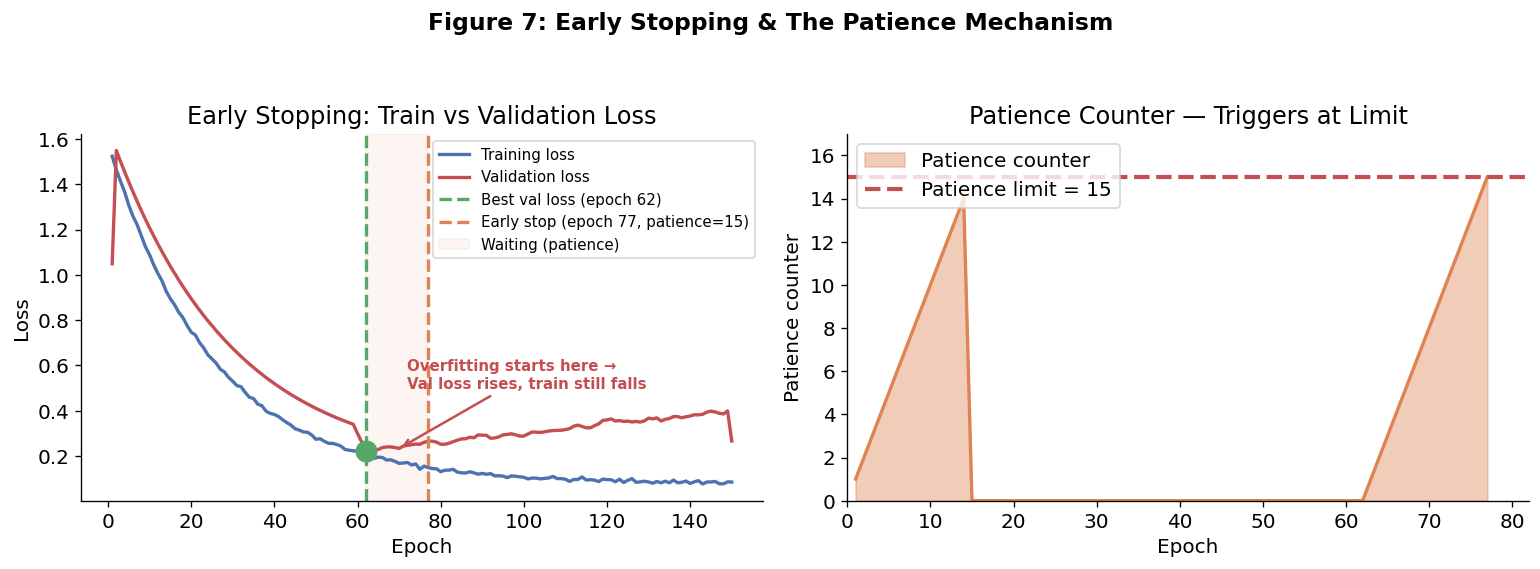

Best epoch: 62 (val_loss=0.2237)
Stop epoch: 77 (patience=15)
Saved 73 wasted epochs → restore weights from epoch 62


In [22]:
# Figure 7: Early Stopping — train vs val curves, patience mechanism
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

epochs = np.arange(1, 151)

# Simulate training/val curves
train_loss = 1.5 * np.exp(-epochs * 0.04) + 0.08 + 0.005*np.random.randn(150)
val_loss   = 1.5 * np.exp(-epochs * 0.035) + 0.15

# Val loss starts increasing after epoch ~60 (overfitting)
overfit_mask = epochs > 60
val_loss[overfit_mask] = (0.22 + 0.002*(epochs[overfit_mask]-60)
                          + 0.012*np.random.randn(overfit_mask.sum()))

# Apply a slight smoothing to make the curve look realistic
val_loss = np.convolve(val_loss, np.ones(3)/3, mode='same')

# Best val epoch
best_epoch = np.argmin(val_loss) + 1
patience   = 15
stop_epoch = min(best_epoch + patience, 150)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Plot 1: Loss curves with annotations ──
axes[0].plot(epochs, train_loss, color='#4C72B0', lw=2, label='Training loss')
axes[0].plot(epochs, val_loss,   color='#C44E52', lw=2, label='Validation loss')
axes[0].axvline(best_epoch, color='#55A868', ls='--', lw=2,
                label=f'Best val loss (epoch {best_epoch})')
axes[0].axvline(stop_epoch, color='#DD8452', ls='--', lw=2,
                label=f'Early stop (epoch {stop_epoch}, patience={patience})')
axes[0].axvspan(best_epoch, stop_epoch, alpha=0.08, color='#DD8452', label='Waiting (patience)')
axes[0].scatter([best_epoch], [val_loss[best_epoch-1]], s=150, color='#55A868', zorder=5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Early Stopping: Train vs Validation Loss')
axes[0].legend(fontsize=9)

# Annotation fixed with \n
axes[0].annotate('Overfitting starts here →\nVal loss rises, train still falls',
                 xy=(70, val_loss[69]), xytext=(72, 0.5),
                 fontsize=9, color='#C44E52', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.5))

# ── Plot 2: Patience counter ──
patience_counter = np.zeros(stop_epoch)
best_so_far = val_loss[0]
counter = 0

for i in range(stop_epoch):
    if val_loss[i] < best_so_far:
        best_so_far = val_loss[i]
        counter = 0
    else:
        counter += 1
    patience_counter[i] = counter

axes[1].fill_between(np.arange(1, stop_epoch+1), patience_counter,
                     color='#DD8452', alpha=0.4, label='Patience counter')
axes[1].plot(np.arange(1, stop_epoch+1), patience_counter,
             color='#DD8452', lw=2)
axes[1].axhline(patience, color='#C44E52', ls='--', lw=2.5,
                label=f'Patience limit = {patience}')
axes[1].set_xlim(0, stop_epoch + 5)
axes[1].set_ylim(0, patience + 2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Patience counter')
axes[1].set_title('Patience Counter — Triggers at Limit')
axes[1].legend(loc='upper left')

plt.suptitle('Figure 7: Early Stopping & The Patience Mechanism', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print(f"Best epoch: {best_epoch} (val_loss={val_loss[best_epoch-1]:.4f})")
print(f"Stop epoch: {stop_epoch} (patience={patience})")
print(f"Saved {150 - stop_epoch} wasted epochs → restore weights from epoch {best_epoch}")


---

## 8. PyTorch Regularization Demo — All Techniques Together

Training the same network with different regularization strategies to compare their effect.


No regularization      | Best val MSE: 0.0309 at epoch 139
L2 (wd=0.01)           | Best val MSE: 0.0264 at epoch 66
Dropout p=0.3          | Best val MSE: 0.0299 at epoch 216
L2 + Dropout           | Best val MSE: 0.0292 at epoch 192


C:\Users\23add\AppData\Local\Temp\ipykernel_11836\38028789.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(list(final_vals.keys()), rotation=15, ha='right', fontsize=9)


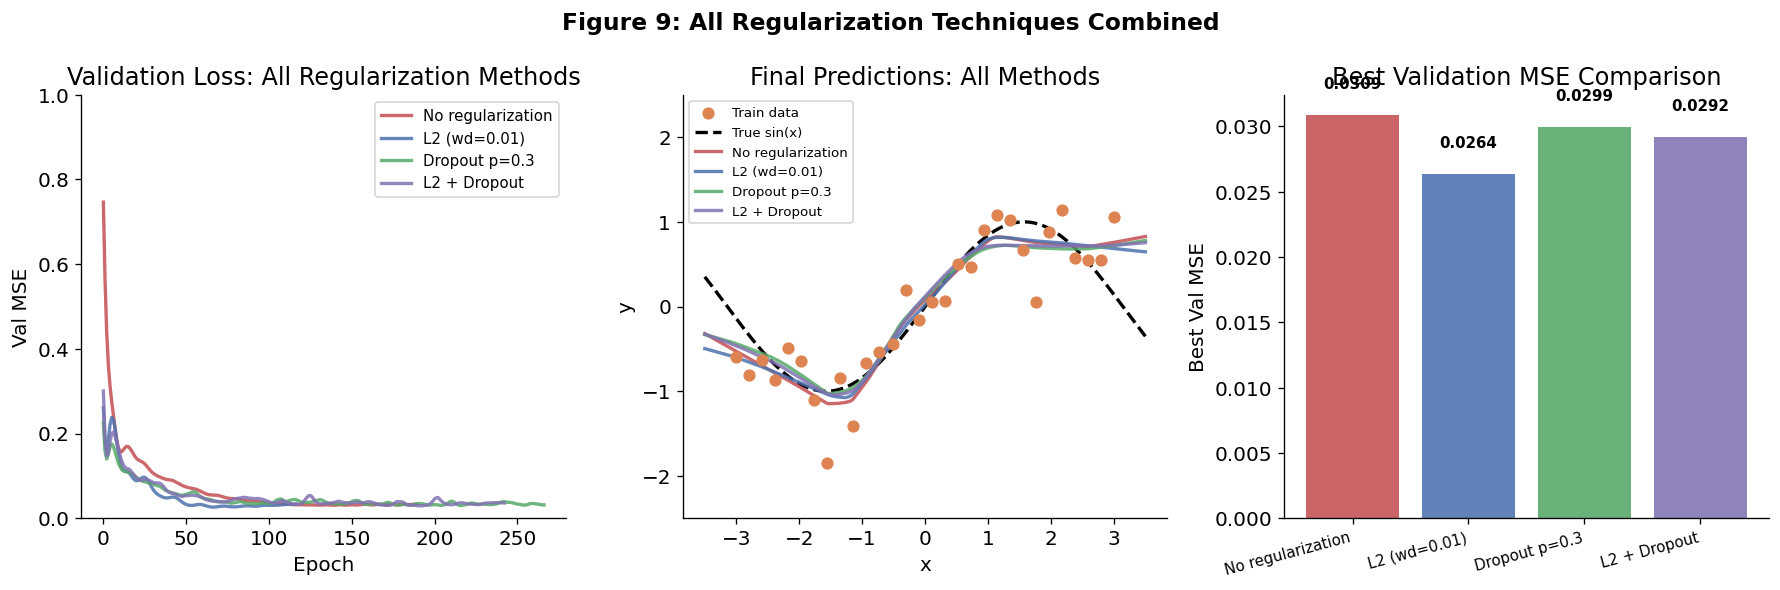

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ── Dataset: small noisy sin regression ───────────────────────────
N_tr, N_val = 30, 200
X_tr  = torch.linspace(-3, 3, N_tr).unsqueeze(1)
y_tr  = torch.sin(X_tr) + 0.4*torch.randn_like(X_tr)
X_val = torch.linspace(-3, 3, N_val).unsqueeze(1)
y_val = torch.sin(X_val)

# ── Base model ────────────────────────────────────────────────────
def make_model(dropout_p=0.0):
    return nn.Sequential(
        nn.Linear(1, 128), nn.ReLU(),
        nn.Dropout(dropout_p),
        nn.Linear(128, 128), nn.ReLU(),
        nn.Dropout(dropout_p),
        nn.Linear(128, 1)
    )

# ── Training function ─────────────────────────────────────────────
def train(model, opt, epochs=1000):
    crit = nn.MSELoss()
    tr_losses, val_losses = [], []
    best_val, best_ep, patience, counter = 1e9, 0, 50, 0

    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        loss = crit(model(X_tr), y_tr)
        loss.backward()
        opt.step()
        tr_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_l = crit(model(X_val), y_val).item()
        val_losses.append(val_l)

        # Early stopping
        if val_l < best_val - 1e-5:
            best_val = val_l
            best_ep = ep
            counter = 0
            best_state = {k: v.clone() for k,v in model.state_dict().items()}
        else:
            counter += 1
        if counter >= patience:
            break

    model.load_state_dict(best_state)
    return tr_losses, val_losses, best_ep

experiments = {
    'No regularization':  (make_model(0.0),   optim.Adam(make_model(0.0).parameters(), lr=1e-3)),
    'L2 (weight_decay)':  (make_model(0.0),   None),
    'Dropout (p=0.3)':    (make_model(0.3),   None),
    'L2 + Dropout':       (make_model(0.3),   None),
}
# Recreate with proper opts (needed because model must match opt)
models_opts = [
    ('No regularization', make_model(0.0), lambda m: optim.Adam(m.parameters(), lr=1e-3, weight_decay=0)),
    ('L2 (wd=0.01)',      make_model(0.0), lambda m: optim.AdamW(m.parameters(), lr=1e-3, weight_decay=0.01)),
    ('Dropout p=0.3',     make_model(0.3), lambda m: optim.Adam(m.parameters(), lr=1e-3, weight_decay=0)),
    ('L2 + Dropout',      make_model(0.3), lambda m: optim.AdamW(m.parameters(), lr=1e-3, weight_decay=0.01)),
]

colors  = ['#C44E52','#4C72B0','#55A868','#8172B3']
results = {}
for name, model, opt_fn in models_opts:
    opt = opt_fn(model)
    tr, val, best_ep = train(model, opt, epochs=1500)
    results[name] = {'tr': tr, 'val': val, 'model': model, 'best_ep': best_ep}
    print(f"{name:22s} | Best val MSE: {min(val):.4f} at epoch {best_ep}")

# ── Plots ──────────────────────────────────────────────────────────
x_plot = torch.linspace(-3.5, 3.5, 300).unsqueeze(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Train vs val curves
for (name, _, __), col in zip(models_opts, colors):
    r = results[name]
    axes[0].plot(r['val'], color=col, lw=2, label=name, alpha=0.85)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val MSE')
axes[0].set_title('Validation Loss: All Regularization Methods')
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 1)

# Final predictions
axes[1].scatter(X_tr.numpy(), y_tr.numpy(), color='#DD8452', s=40, zorder=5, label='Train data')
axes[1].plot(x_plot.numpy(), torch.sin(x_plot).numpy(), 'k--', lw=2, label='True sin(x)')
for (name, _, __), col in zip(models_opts, colors):
    m = results[name]['model']
    m.eval()
    with torch.no_grad():
        y_pred = m(x_plot).numpy()
    axes[1].plot(x_plot.numpy(), y_pred, color=col, lw=2, label=name, alpha=0.85)
axes[1].set_ylim(-2.5, 2.5); axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Final Predictions: All Methods'); axes[1].legend(fontsize=8)

# Val loss comparison bar
final_vals = {name: min(results[name]['val']) for name, *_ in models_opts}
bars = axes[2].bar(list(final_vals.keys()), list(final_vals.values()),
                   color=colors, alpha=0.88)
axes[2].set_ylabel('Best Val MSE'); axes[2].set_title('Best Validation MSE Comparison')
axes[2].set_xticklabels(list(final_vals.keys()), rotation=15, ha='right', fontsize=9)
for bar, v in zip(bars, final_vals.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 9: All Regularization Techniques Combined', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Combining Regularization Methods

A very common question when building deep learning models is: *"Should I just throw every single regularization technique (L1 + L2 + Early Stopping + Dropout + Batch Normalization) at my model at the same time?"*

The short answer is: **Yes, you should combine them, but strategically.** Some techniques complement each other perfectly, while others mathematically conflict or are entirely redundant.

---

### 9.1 The "Golden Trio" (The Industry Default)

The standard recipe for training almost all modern Deep Learning architectures (from Transformers to massive Dense Networks) uses this specific combination:
**L2 Regularization (AdamW) + Dropout + Early Stopping**

**Why they complement each other:**
They do not conflict because they attack overfitting from three entirely independent mathematical angles:
1.  **L2 Weight Decay** restricts the **Magnitude**. It forces the physical values of the parameter matrices to stay small and smooth.
2.  **Dropout** restricts the **Architecture**. Even with small weights, neurons can co-adapt and rely on specific "star" features. Dropout randomly destroys pathways, forcing the network to learn robust, redundant representations.
3.  **Early Stopping** restricts **Time**. Even with L2 and Dropout, given infinite epochs, gradient descent will eventually tunnel into the training noise. Early stopping halts the optimizer exactly at the optimal generalization point on the U-Curve.

*   **Pros:** Maximum defense against overfitting with no mathematical friction.
*   **Cons:** You must tune multiple hyperparameters simultaneously (Weight decay $\lambda$, Dropout rate $p$, and Patience).

---

### 9.2 The "Grouped Selection" Combo (Classical ML)

**L1 Regularization + L2 Regularization = Elastic Net**

*   **When to use it:** Classical Machine Learning (Linear/Logistic Regression) on wide, tabular datasets where you suspect many features are useless or highly correlated (e.g., Genomics).
*   **Why they complement each other:** L1 acts as a "bulldozer," aggressively pushing useless features to exactly `0` (Feature Selection). L2 acts as a "rubber band," ensuring that if a cluster of features are highly correlated, the model doesn't just pick one at random and destroy the rest, but rather groups them stably.
*   **Why we skip it in Deep Learning:** Exact sparse matrices (L1) do not actually compute faster on modern dense GPUs. Furthermore, the non-differentiable absolute value derivative adds unnecessary complexity to backpropagation. Deep networks rely on L2 and Dropout instead.

---

### 9.3 The "Disharmony" Conflict (What NOT to Combine)

**Dropout + Batch Normalization**

*   **The Combination:** Placing a standard Dropout layer immediately preceding or following a Batch Normalization layer.
*   **The Problem:** These two methods **actively fight each other**. 
    *   Batch Normalization relies on calculating the precise, stable statistical Mean and Variance of the incoming mini-batch. 
    *   Dropout randomly zeroes out up to 50% of the activations at every single step. 
*   **The Result:** By randomly destroying half the data, Dropout injects massive, unpredictable fluctuations into the true variance of the layer. This corrupts the running statistics that Batch Normalization is desperately trying to track, leading to severe training instability (a phenomenon formally known as *The Variance Shift*).
*   **The Solution:** Modern ResNets and CNNs usually abandon standard Dropout entirely in their convolutional blocks, relying safely on the implicit regularizing power of Batch Normalization. If you *must* use both in a dense network, use a very low dropout rate (e.g., `0.1`) and place the Dropout layer *after* all Batch Norm layers have successfully calculated their statistics.

---

### The Ultimate Regularization Checklist

When designing your model architecture, follow this decision tree:

1.  **Mandatory Baseline:** Always implement **Early Stopping**. It is computationally free and acts as the ultimate safety net against extreme overtraining.
2.  **Default Weight Constraint:** Always use **L2 Weight Decay** (specifically via decoupled `AdamW`). Start with $\lambda$ = `1e-4`.
3.  **For Convolutional Networks (CNNs):** heavily rely on **Data Augmentation** and **Batch Normalization**. Avoid standard Dropout.
4.  **For Transformers & Dense Networks:** heavily rely on **Dropout** (rates between `0.1` and `0.5`).
5.  **For Feature Selection (Tabular ML):** Use **L1 or Elastic Net**.

---

### Master Interview Q&A: Combining Methods

> **Q: Why do modern deep learning researchers use L2 Weight Decay, Dropout, and Early Stopping simultaneously? Don't they basically do the exact same thing?**
> 
> **A:** While they all share the overarching goal of reducing Variance, they operate on completely orthogonal mechanisms. L2 physically acts on the parameter values themselves (a magnitude penalty). Dropout mathematically acts on the network topology (breaking co-adaptation via random silencing). Early Stopping acts purely on the training duration (preventing noise memorization over time). Using them together provides a multi-faceted defense without causing diminishing returns or mathematical conflicts.

> **Q: Briefly explain the "Disharmony" problem, and why combining standard Dropout with Batch Normalization often degrades model accuracy.**
> 
> **A:** Batch Normalization maintains running statistics (mean and variance) during training to accurately normalize outputs at test time. Dropout fundamentally operates by injecting massive random noise (zeroing out a large percentage of activations). When placed together, the random silencing from Dropout aggressively shifts the true variance of the activations. This mathematically corrupts the moving average statistics Batch Norm is trying to track. Because the tracked test-time variance no longer matches the true training variance, the model's predictions degrade during inference.


## 9. Master Interview Q&A Cheatsheet: Regularization

This cheat sheet compiles the most critical regularization concepts tested in Machine Learning and Deep Learning interviews, structured from beginner intuition to senior-level architectural design.

---

### Level 1 — Beginner (Core Concepts)

> **Q: What is overfitting in plain English, and how do you explicitly detect it during training?**
> 
> **A:** Overfitting occurs when a model stops learning the underlying, generalized patterns of a dataset and begins to simply memorize the random noise and outliers specific to the training set. It is like a student memorizing the exact answers to a practice test but failing the real exam. We detect it by monitoring the **Training Loss** and **Validation Loss** simultaneously. If the Training Loss continues to go down while the Validation Loss stops improving and begins to climb back up (forming a U-shape), the model is actively overfitting.

> **Q: Name 3 standard regularization techniques used in Neural Networks and briefly explain what they do.**
> 
> **A:** 
> 1. **L2 Regularization (Weight Decay):** Acts as a mathematical "rubber band," penalizing large weights and forcing the optimizer to distribute importance across many features rather than relying on a few massive outlier weights.
> 2. **Dropout:** Randomly zeroes out a percentage of neurons during every training step. This acts as a "bus factor," preventing neurons from co-adapting and relying on a single "star" feature, forcing the network to learn robust, redundant pathways.
> 3. **Early Stopping:** Monitors the validation loss and physically halts the training process the moment performance starts degrading, preventing the model from having the time to memorize the training noise.

> **Q: How does simply gathering more training data act as a form of regularization?**
> 
> **A:** Regularization is fundamentally about restricting the model from memorizing noise. When you have a massive dataset, the random noise naturally cancels itself out across millions of examples, revealing only the true underlying statistical patterns. Because the model is exposed to a broader, more complete view of the universe, it mathematically cannot memorize the individual noise of every single data point. Therefore, more data acts as the ultimate natural regularizer, reducing Variance without needing to artificially inject Bias.

---

### Level 2 — Mid-Level (Mathematical & Architectural Mechanics)

> **Q: Compare L1 and L2 Regularization. Geometrically, why does L1 produce sparse matrices (exact zeros) while L2 only shrinks them?**
> 
> **A:** L2 (Ridge) uses squared weights ($w^2$), which geometrically creates a smooth, continuous **circle** as a constraint boundary. The optimization contours almost always graze this circle at a point where all weights are small, non-zero decimals. L1 (Lasso) uses absolute values ($|w|$), which geometrically creates a sharp **diamond**. The optimization contours natively hit the pointy, protruding corners of this diamond first. Because those corners rest precisely on the coordinate axes, one or more of the corresponding weights are mathematically forced to become exactly `0`, resulting in a sparse, feature-selected model.

> **Q: What is "Inverted Dropout", and why does PyTorch use it under the hood instead of Vanilla Dropout?**
> 
> **A:** With Dropout, if you disable 50% of the neurons during training, the next layer expects half the signal. At test time, when you turn all neurons back on, the signal is suddenly twice as strong, destroying the predictions. The historical "Vanilla" fix was to mathematically scale millions of weights at test time, which slowed down inference. **Inverted Dropout** shifts the math to the *training* phase: immediately after dropping the neurons, it multiplies the surviving neurons by $\frac{1}{1-p}$. This ensures the expected mathematical sum of the activations remains perfectly identical between train and test phases. PyTorch uses this so the model can run at maximum speed during test time with zero computational scaling required.

> **Q: Explain the exact physical and mathematical definition of the Bias-Variance Tradeoff.**
> 
> **A:** It is the foundational equation defining the Total Expected Error of any model: `Error = Bias^2 + Variance + Noise`. 
> **Bias** is the error introduced when a model is mathematically too simple to capture the underlying pattern (Underfitting). **Variance** is the error introduced when a model is too hyper-sensitive to the specific training data, fluctuating wildly if trained on a different set (Overfitting). Regularization techniques intentionally inject a tiny amount of Bias (e.g., restricting weight sizes) in exchange for a massive, disproportionate drop in Variance, resulting in a lower Total Error on unseen data.

---

### Level 3 — Senior MLE / Staff Engineer (System Design & Debugging)

> **Q: Your massive ResNet-50 Computer Vision model is currently achieving 3% below target accuracy on the Validation set. Walk me through your specific regularization debugging checklist.**
> 
> **A:** First, I would graph the Training vs. Validation curves. If Training accuracy is *not* near 99%, the model is underfitting, and adding regularization will actually make it worse. Assuming it *is* overfitting (Train Acc >> Val Acc):
> 1. **Check the Optimizer Combo:** Ensure we are using decoupled `AdamW` (not standard `Adam`, which corrupts the L2 penalty) with a starting `weight_decay` of `1e-4`.
> 2. **Audit Dropout layers:** In modern CNNs, Dropout should **never** be used in the convolutional feature blocks (it fails to break spatial correlation). Spatial Dropout is an option, but ideally, Dropout should strictly be reserved for the final Dense classification head.
> 3. **Data Augmentation:** Ensure heavy stochastic augmentations (MixUp, CutMix, RandAugment) are applied to artificially expand the dataset distribution.
> 4. **Early Stopping Check:** Verify that we are reloading the weights from the epoch with the absolute minimum validation loss, not deploying the model as it existed when the patience timer finally ran out.

> **Q: A Junior Engineer placed a Dropout layer immediately preceding a Batch Normalization layer, and the training curve has become highly unstable. Explain mathematically why this "Disharmony" problem is occurring.**
> 
> **A:** Batch Normalization stabilizes deep networks by dynamically calculating the running Mean and Variance of the activations passing through it during a mini-batch. When Dropout is placed immediately beforehand, it stochastically zeroes out 50% of the activations at every step. This injects massive, artificial variance into the data stream. The Batch Norm layer blindly incorporates this artificial dropout noise into its running statistics. At test time, when Dropout is turned off, the true variance of the dense inputs no longer matches the corrupted variance statistics saved by the Batch Norm layer. This "Variance Shift" systematically degrades inference accuracy. The architectural fix is to either drop Dropout entirely and rely on BN's implicit regularization, or place Dropout strictly *after* all Batch Norm statistics have been finalized.

> **Q: Explain the concept of "Implicit Regularization" within the mechanics of Mini-Batch Stochastic Gradient Descent (SGD).**
> 
> **A:** Unlike true Gradient Descent (which calculates the exact mathematical direction using the entire dataset), Mini-Batch SGD only looks at a tiny subset of data per step. Because this subset is a poor approximation of the whole, the calculated gradient direction points slightly in the wrong direction. This inherent "noise" acts as an incredibly powerful implicit regularizer. The optimizer isn't allowed to smoothly slide into sharp, narrow validation valleys (which overfit). Instead, the constant stochastic bouncing physically kicks the optimizer out of narrow valleys, forcing it to eventually settle into broad, flat minima. Flat minima are mathematically proven to generalize better to unseen test data. (Consequently, this is why training with massive, 8,000+ batch sizes often results in worse test accuracy unless heavy explicit regularization is applied to compensate for the lost noise).
